In [1]:
#!/usr/bin/env python
# coding: utf-8

# =============================================================================
# 导入库，设置绘图参数
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import r2_score
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

Path('figures/independent_comparison').mkdir(parents=True, exist_ok=True)
Path('results').mkdir(exist_ok=True)

sns.set_context("paper")
sns.set_palette('muted')

ss   = 10
sss  = 8
ssss = 6

matplotlib.rcParams['figure.figsize']   = (3.2, 2.8)
matplotlib.rcParams['figure.dpi']       = 600
matplotlib.rcParams['font.sans-serif']  = ['Arial']
matplotlib.rcParams['font.family']      = 'sans-serif'
matplotlib.rcParams['font.style']       = 'normal'
matplotlib.rcParams['font.weight']      = 'bold'
matplotlib.rcParams['axes.labelweight'] = 'bold'
matplotlib.rcParams['axes.titlesize']   = sss
matplotlib.rcParams['legend.fontsize']  = ss
matplotlib.rcParams['axes.labelsize']   = ss
matplotlib.rcParams['xtick.labelsize']  = ss
matplotlib.rcParams['ytick.labelsize']  = ss
matplotlib.rcParams['axes.linewidth']   = 0.6
matplotlib.rcParams['lines.linewidth']  = 1.0
matplotlib.rcParams['axes.grid']        = False

COLOR_MAP  = {'cv': 'steelblue', 'independent': 'coral',
               'edge': 'tab:orange', 'interior': 'tab:blue'}
ref_line_size = 0.8

# =============================================================================
# 模型配置
# =============================================================================

MODELS_TO_COMPARE = ['ridge', 'svr', 'rf', 'xgb', 'dnn']
MODEL_NAME_MAP    = {'ridge': 'RR', 'svr': 'SVR', 'rf': 'RFR',
                     'xgb': 'XGB', 'dnn': 'DNN'}

models      = MODELS_TO_COMPARE
model_names = [MODEL_NAME_MAP[m] for m in models]

# =============================================================================
# 加载数据
# =============================================================================

ind_results_all              = {}
ind_correction_comparison_all= {}
cv_results_all               = {}
missing_models               = []

for model in models:
    try:
        with open(f'models/{model}/independent_test_results.json', 'r') as f:
            ind_results_all[model] = json.load(f)
        with open(f'models/{model}/{model}_results.json', 'r') as f:
            cv_results_all[model] = json.load(f)
        comp_path = Path(f'models/{model}/independent_test_correction_comparison.csv')
        if comp_path.exists():
            ind_correction_comparison_all[model] = pd.read_csv(comp_path)
        print(f"✓ 加载 {model}")
    except FileNotFoundError as e:
        print(f"✗ 无法加载 {model}: {e}")
        missing_models.append(model)

for m in missing_models:
    models.remove(m); model_names.remove(MODEL_NAME_MAP[m])

assert len(models) > 0, "没有可用的独立测试结果！"
print(f"实际对比: {len(models)} 个模型")

# =============================================================================
# 提取整体性能（校正前/后）、边缘vs内部、原子类型
# =============================================================================

atom_type_labels = ['O', 'C', 'Ti_inner', 'Ti_outer']

def _get_before(results):
    return results['before_correction'] if 'before_correction' in results else results

def _get_after(results):
    return results['after_correction'] if 'after_correction' in results else _get_before(results)

ind_overall_before = []
ind_overall_after  = []
for model, name in zip(models, model_names):
    r = ind_results_all[model]
    b = _get_before(r); a = _get_after(r)
    ind_overall_before.append({'model_id': model, 'Model': name,
        'MAE': b['overall']['mae'], 'RMSE': b['overall']['rmse'],
        'R2':  b['overall']['r2'],  'N': b['overall']['n_samples']})
    ind_overall_after.append({'model_id': model, 'Model': name,
        'MAE': a['overall']['mae'], 'RMSE': a['overall']['rmse'],
        'R2':  a['overall']['r2'],  'N': a['overall']['n_samples']})

df_ind_overall_before = pd.DataFrame(ind_overall_before)
df_ind_overall_after  = pd.DataFrame(ind_overall_after)
df_ind_overall_combined = df_ind_overall_before.copy()
df_ind_overall_combined['MAE_Before'] = df_ind_overall_before['MAE']
df_ind_overall_combined['MAE_After']  = df_ind_overall_after['MAE']
df_ind_overall_combined['MAE_Improvement_%'] = (
    (df_ind_overall_before['MAE'] - df_ind_overall_after['MAE']) /
     df_ind_overall_before['MAE'] * 100)

# 电荷偏差统计
charge_stats = []
for model, name in zip(models, model_names):
    r = ind_results_all[model]
    if 'correction_stats' in r:
        s = r['correction_stats']
        charge_stats.append({'model_id': model, 'Model': name,
            'Mean_Q_total_Before': s['mean_Q_total_before'],
            'Max_Q_total_Before':  s['max_Q_total_before'],
            'Mean_Q_total_After':  s['mean_Q_total_after'],
            'Max_Q_total_After':   s['max_Q_total_after'],
            'Mean_Correction':     s['mean_correction_amount'],
            'Max_Correction':      s['max_correction_amount'],
            'MAE_Improvement_%':   s.get('mae_improvement_percent', 0)})
    else:
        charge_stats.append({'model_id': model, 'Model': name,
            'Mean_Q_total_Before': np.nan, 'Max_Q_total_Before': np.nan,
            'Mean_Q_total_After':  np.nan, 'Max_Q_total_After':  np.nan,
            'Mean_Correction':     np.nan, 'Max_Correction':     np.nan,
            'MAE_Improvement_%':   0})
df_charge_stats = pd.DataFrame(charge_stats)

# CV vs Independent
cv_vs_ind = []
for model, name in zip(models, model_names):
    cv = cv_results_all[model]['cv_results']
    cv_test  = cv['test']; cv_train = cv['train']
    b = _get_before(ind_results_all[model])
    a = _get_after(ind_results_all[model])
    cv_vs_ind.append({'model_id': model, 'Model': name,
        'CV_Train_MAE':         cv_train['overall']['mae_mean'],
        'CV_Test_MAE':          cv_test['overall']['mae_mean'],
        'Ind_MAE_Before':       b['overall']['mae'],
        'Ind_MAE_After':        a['overall']['mae'],
        'MAE_Change_%_Before':  (b['overall']['mae'] - cv_test['overall']['mae_mean']) / cv_test['overall']['mae_mean'] * 100,
        'MAE_Change_%_After':   (a['overall']['mae'] - cv_test['overall']['mae_mean']) / cv_test['overall']['mae_mean'] * 100,
        'CV_Test_R2':           cv_test['overall']['r2_mean'],
        'Ind_R2_Before':        b['overall']['r2'],
        'Ind_R2_After':         a['overall']['r2'],
        'n_structures': ind_results_all[model].get('n_structures', 0),
        'n_atoms':      ind_results_all[model].get('n_atoms', 0)})
df_cv_vs_ind = pd.DataFrame(cv_vs_ind)

# 边缘vs内部
ind_class_before = []; ind_class_after = []
for model, name in zip(models, model_names):
    cv_test = cv_results_all[model]['cv_results']['test']
    b = _get_before(ind_results_all[model])
    a = _get_after(ind_results_all[model])
    cv_ratio  = cv_test['edge']['mae_mean'] / cv_test['interior']['mae_mean']
    ind_ratio_b = b['edge']['mae'] / b['interior']['mae']
    ind_ratio_a = a['edge']['mae'] / a['interior']['mae']
    ind_class_before.append({'model_id': model, 'Model': name,
        'CV_Edge_MAE':     cv_test['edge']['mae_mean'],
        'CV_Interior_MAE': cv_test['interior']['mae_mean'],
        'CV_Ratio': cv_ratio,
        'Ind_Edge_MAE':     b['edge']['mae'], 'Ind_Interior_MAE': b['interior']['mae'],
        'Ind_Ratio': ind_ratio_b,
        'Ratio_Change_%': (ind_ratio_b - cv_ratio) / cv_ratio * 100,
        'Edge_N': b['edge']['n_samples'], 'Interior_N': b['interior']['n_samples']})
    ind_class_after.append({'model_id': model, 'Model': name,
        'Ind_Edge_MAE': a['edge']['mae'], 'Ind_Interior_MAE': a['interior']['mae'],
        'Ind_Ratio': ind_ratio_a,
        'Edge_N': a['edge']['n_samples'], 'Interior_N': a['interior']['n_samples']})
df_ind_class_before = pd.DataFrame(ind_class_before)
df_ind_class_after  = pd.DataFrame(ind_class_after)

# 按原子类型
ind_at_before = []; ind_at_after = []
for model, name in zip(models, model_names):
    b = _get_before(ind_results_all[model])
    a = _get_after(ind_results_all[model])
    for label in atom_type_labels:
        d = b['by_atom_type'][label]
        ind_at_before.append({'model_id': model, 'Model': name, 'Atom_Type': label,
            'MAE': d['mae'], 'RMSE': d['rmse'], 'R2': d['r2'], 'N': d['n_samples']})
        d2 = a['by_atom_type'][label]
        ind_at_after.append({'model_id': model, 'Model': name, 'Atom_Type': label,
            'MAE': d2['mae'], 'RMSE': d2['rmse'], 'R2': d2['r2'], 'N': d2['n_samples']})
df_ind_at_before = pd.DataFrame(ind_at_before)
df_ind_at_after  = pd.DataFrame(ind_at_after)

# 排名
df_ranked_before    = df_ind_overall_before.sort_values('MAE').reset_index(drop=True)
df_ranked_after     = df_ind_overall_after.sort_values('MAE').reset_index(drop=True)
df_generalization   = df_cv_vs_ind.sort_values('MAE_Change_%_Before').reset_index(drop=True)

# 排名变化
rank_before_dict = {row['Model']: idx+1 for idx, row in df_ranked_before.iterrows()}
rank_after_dict  = {row['Model']: idx+1 for idx, row in df_ranked_after.iterrows()}
rank_changes = [{'Model': name, 'model_id': m,
                  'Rank_Before': rank_before_dict[name], 'Rank_After': rank_after_dict[name],
                  'Change': rank_before_dict[name] - rank_after_dict[name],
                  'Symbol': '↑' if rank_before_dict[name] > rank_after_dict[name]
                             else ('↓' if rank_before_dict[name] < rank_after_dict[name] else '→')}
                 for m, name in zip(models, model_names)]
df_rank_changes = pd.DataFrame(rank_changes)

print("\n【校正前】独立测试集排名:")
for idx, row in df_ranked_before.iterrows():
    print(f"  {idx+1}. {row['Model']:6s}: MAE={row['MAE']:.5f}")
print("\n【校正后】独立测试集排名:")
for idx, row in df_ranked_after.iterrows():
    imp = df_ind_overall_combined[df_ind_overall_combined['Model']==row['Model']]['MAE_Improvement_%'].values[0]
    print(f"  {idx+1}. {row['Model']:6s}: MAE={row['MAE']:.5f} (改善{imp:+.2f}%)")
print("\n泛化能力排名:")
for idx, row in df_generalization.iterrows():
    chg = row['MAE_Change_%_Before']
    grade = "A+" if chg<10 else ("A" if chg<20 else ("B" if chg<30 else "C"))
    print(f"  {idx+1}. {row['Model']:6s}: {chg:+.2f}%  ({grade})")



✓ 加载 ridge
✓ 加载 svr
✓ 加载 rf
✓ 加载 xgb
✓ 加载 dnn
实际对比: 5 个模型

【校正前】独立测试集排名:
  1. RFR   : MAE=0.00303
  2. XGB   : MAE=0.00446
  3. RR    : MAE=0.00881
  4. DNN   : MAE=0.01908
  5. SVR   : MAE=0.02625

【校正后】独立测试集排名:
  1. RFR   : MAE=0.00310 (改善-2.09%)
  2. XGB   : MAE=0.00474 (改善-6.30%)
  3. RR    : MAE=0.00876 (改善+0.60%)
  4. DNN   : MAE=0.01872 (改善+1.87%)
  5. SVR   : MAE=0.02625 (改善+0.03%)

泛化能力排名:
  1. RFR   : -28.16%  (A+)
  2. RR    : -25.10%  (A+)
  3. DNN   : -13.63%  (A+)
  4. XGB   : -9.56%  (A+)
  5. SVR   : +197.76%  (C)


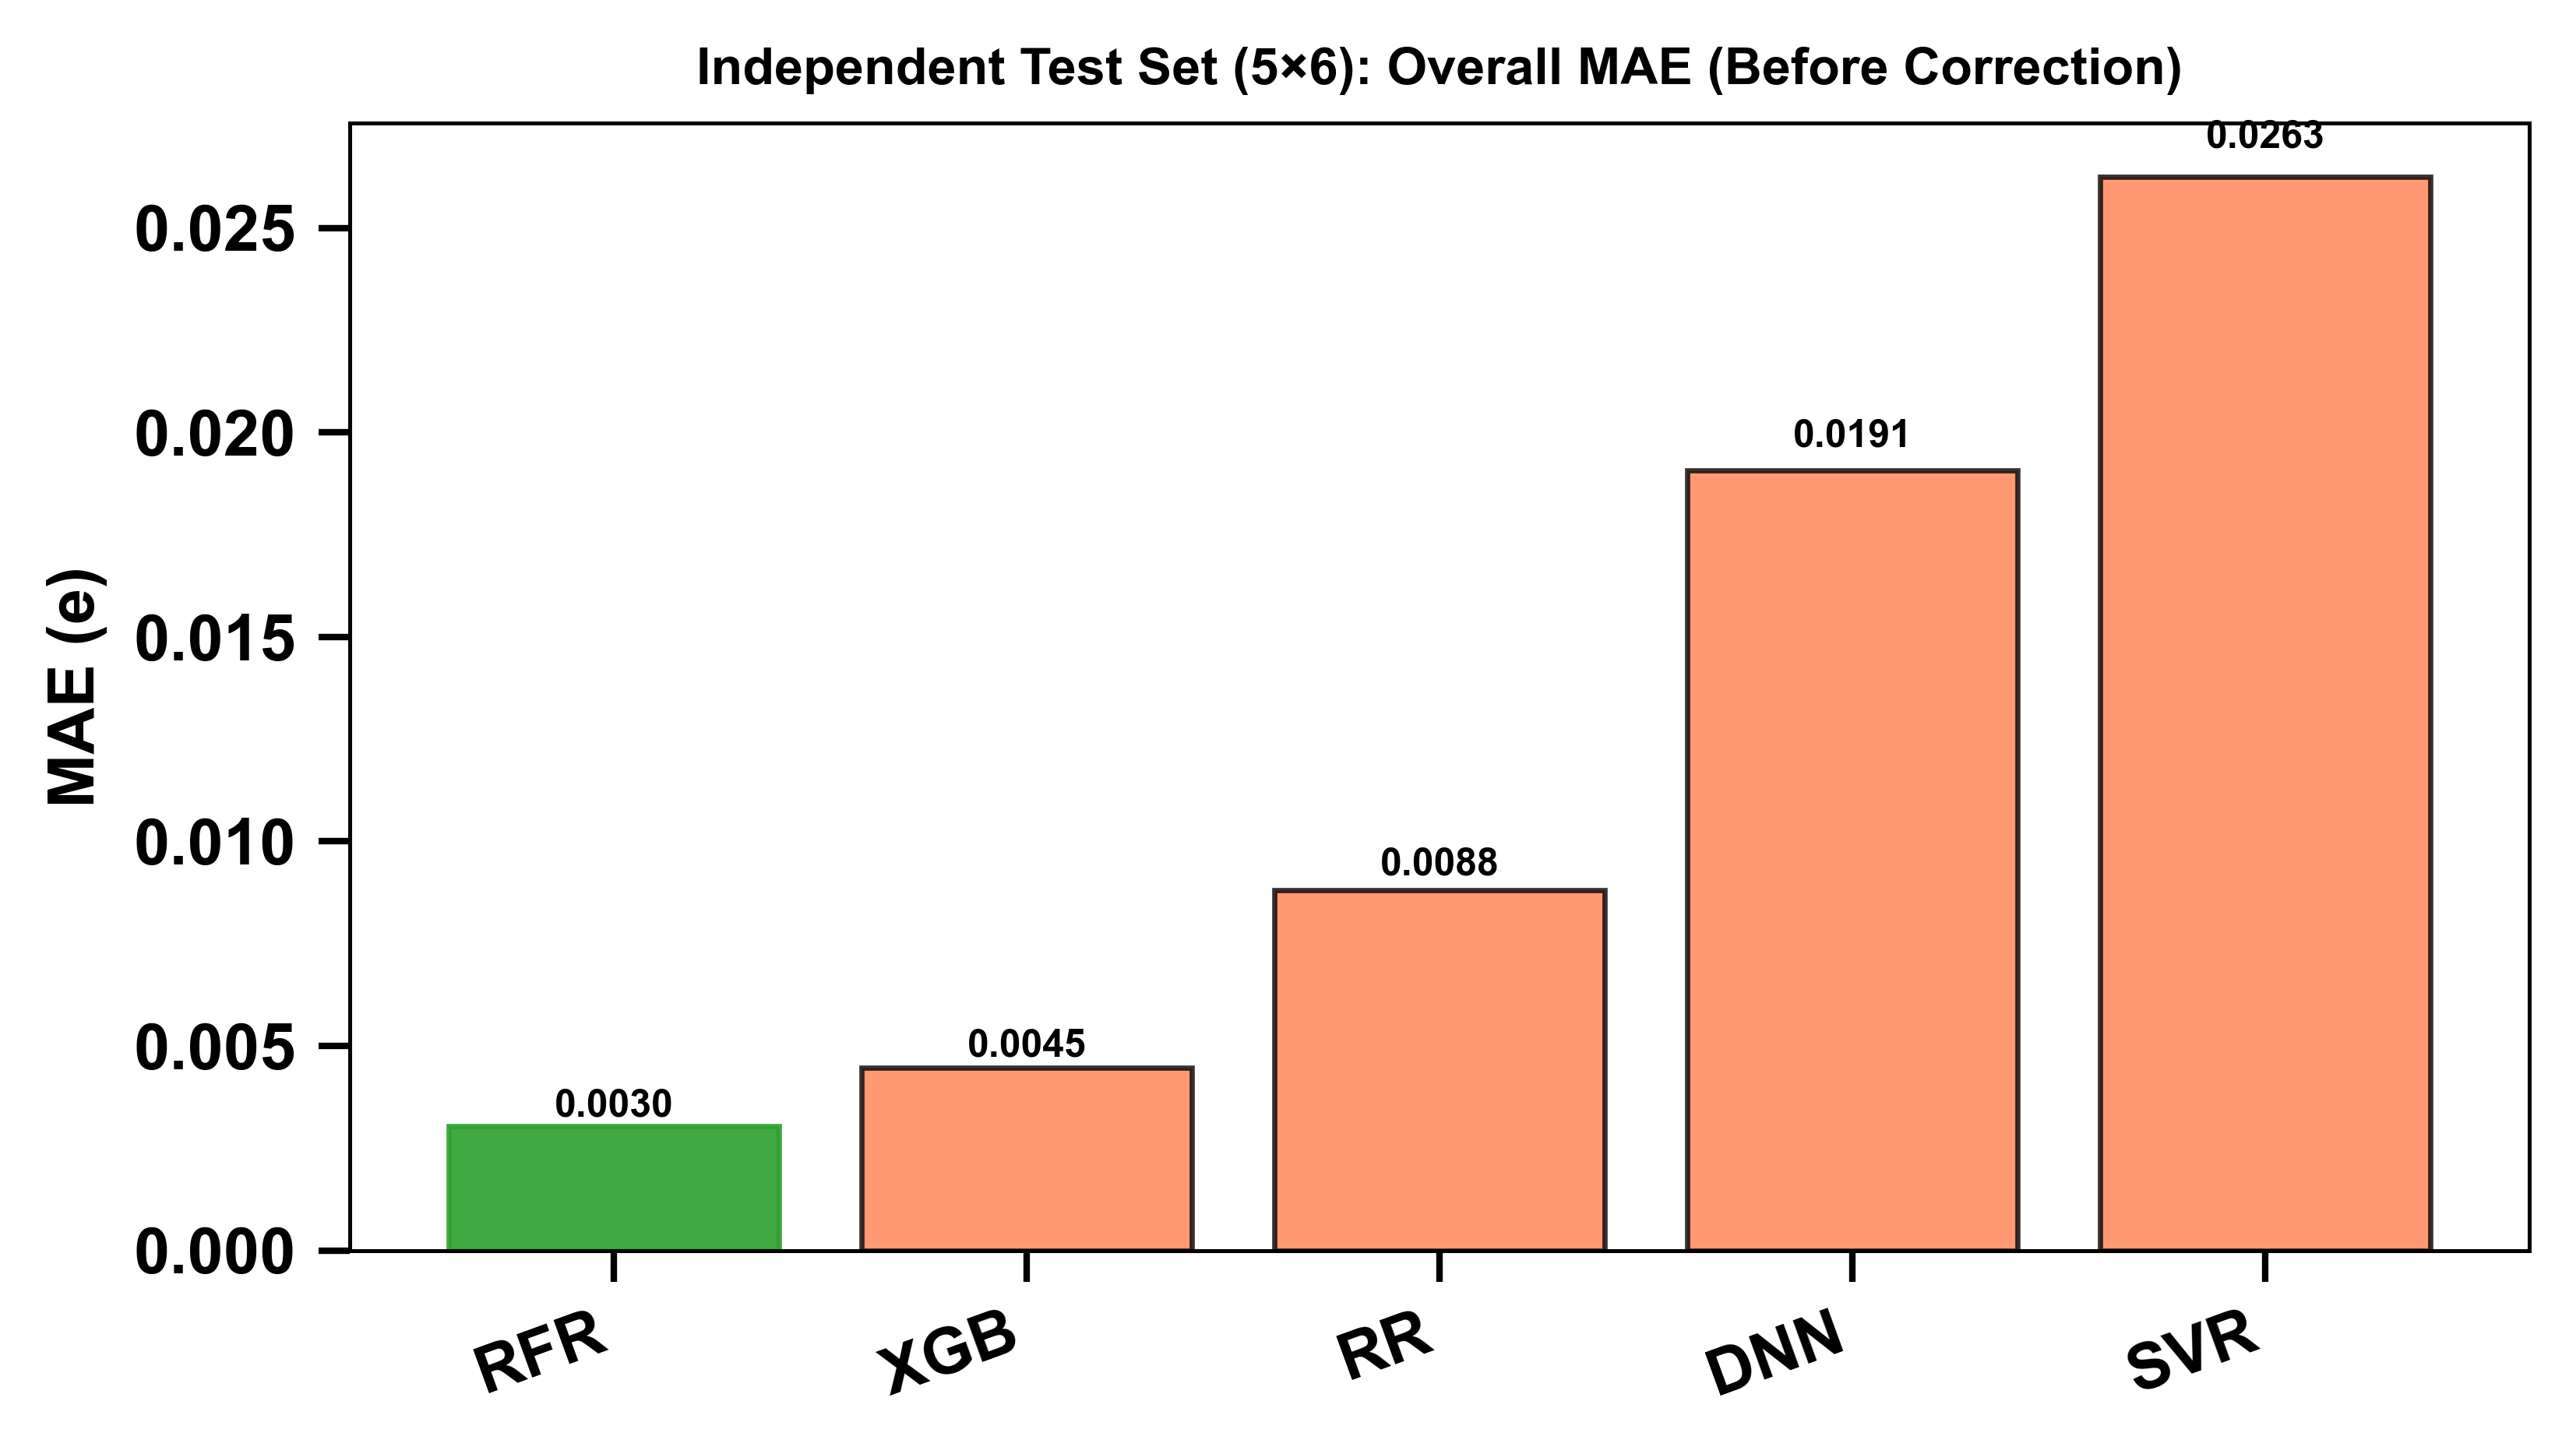

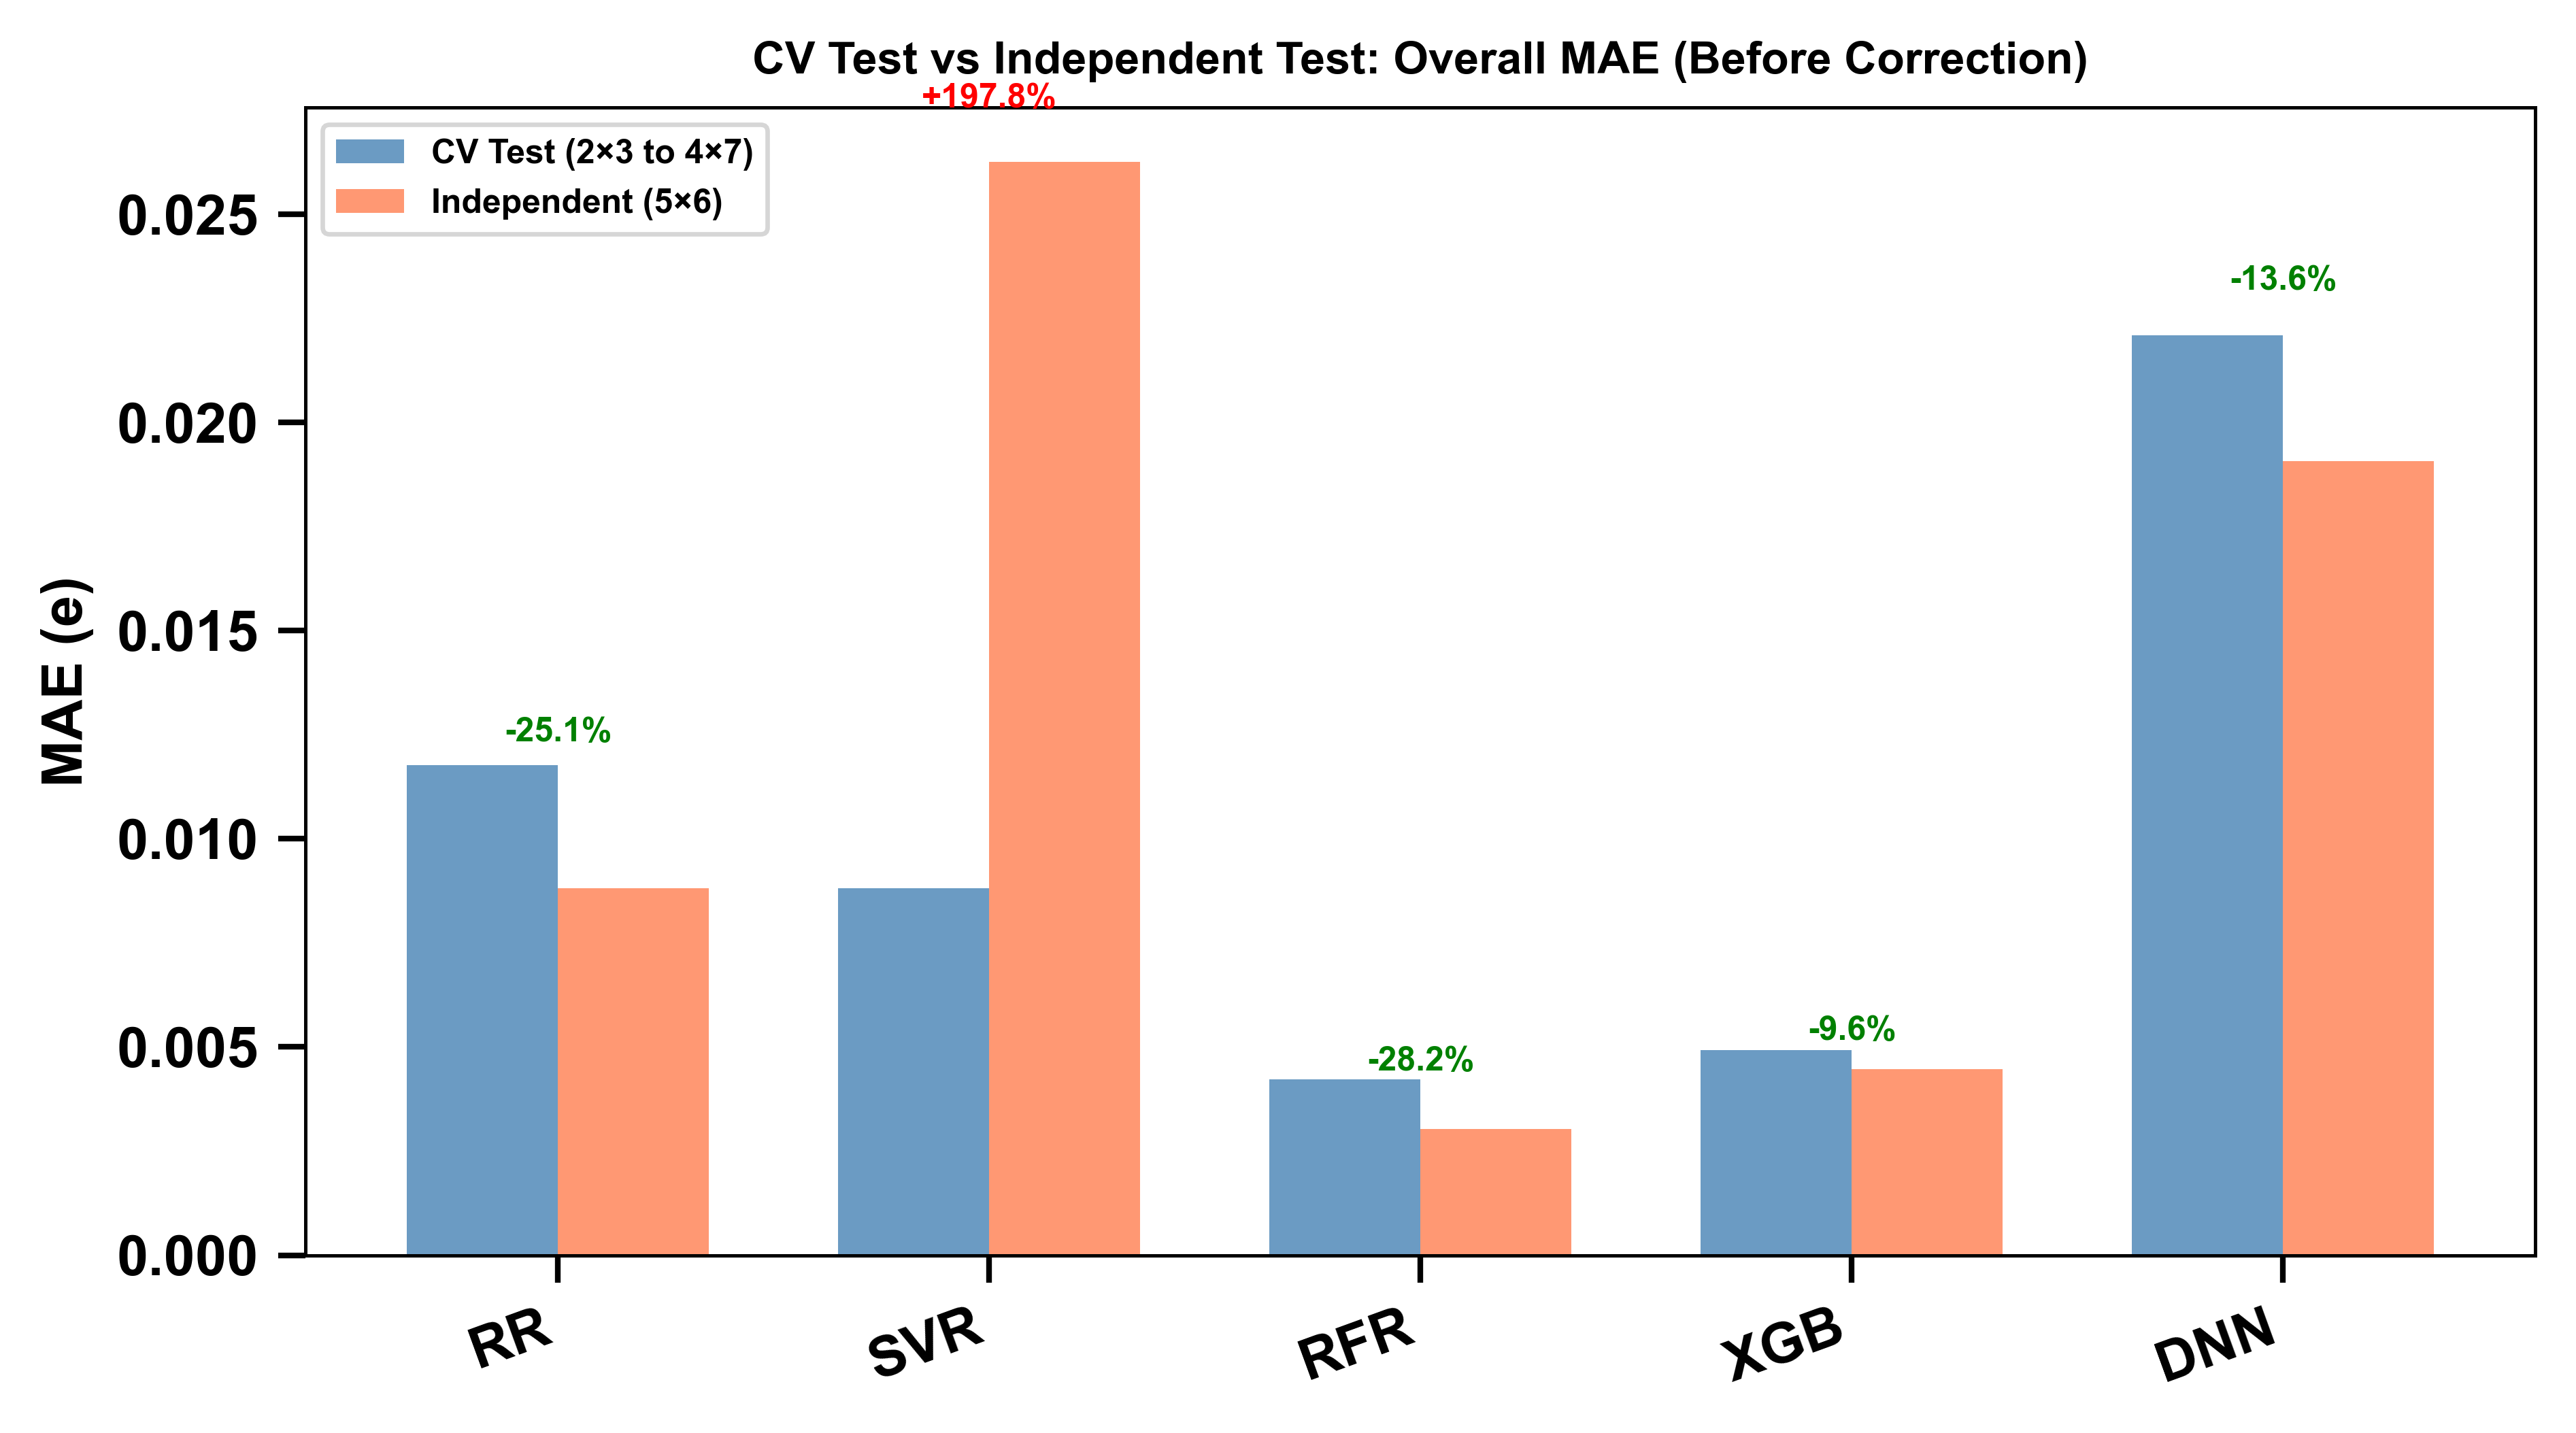

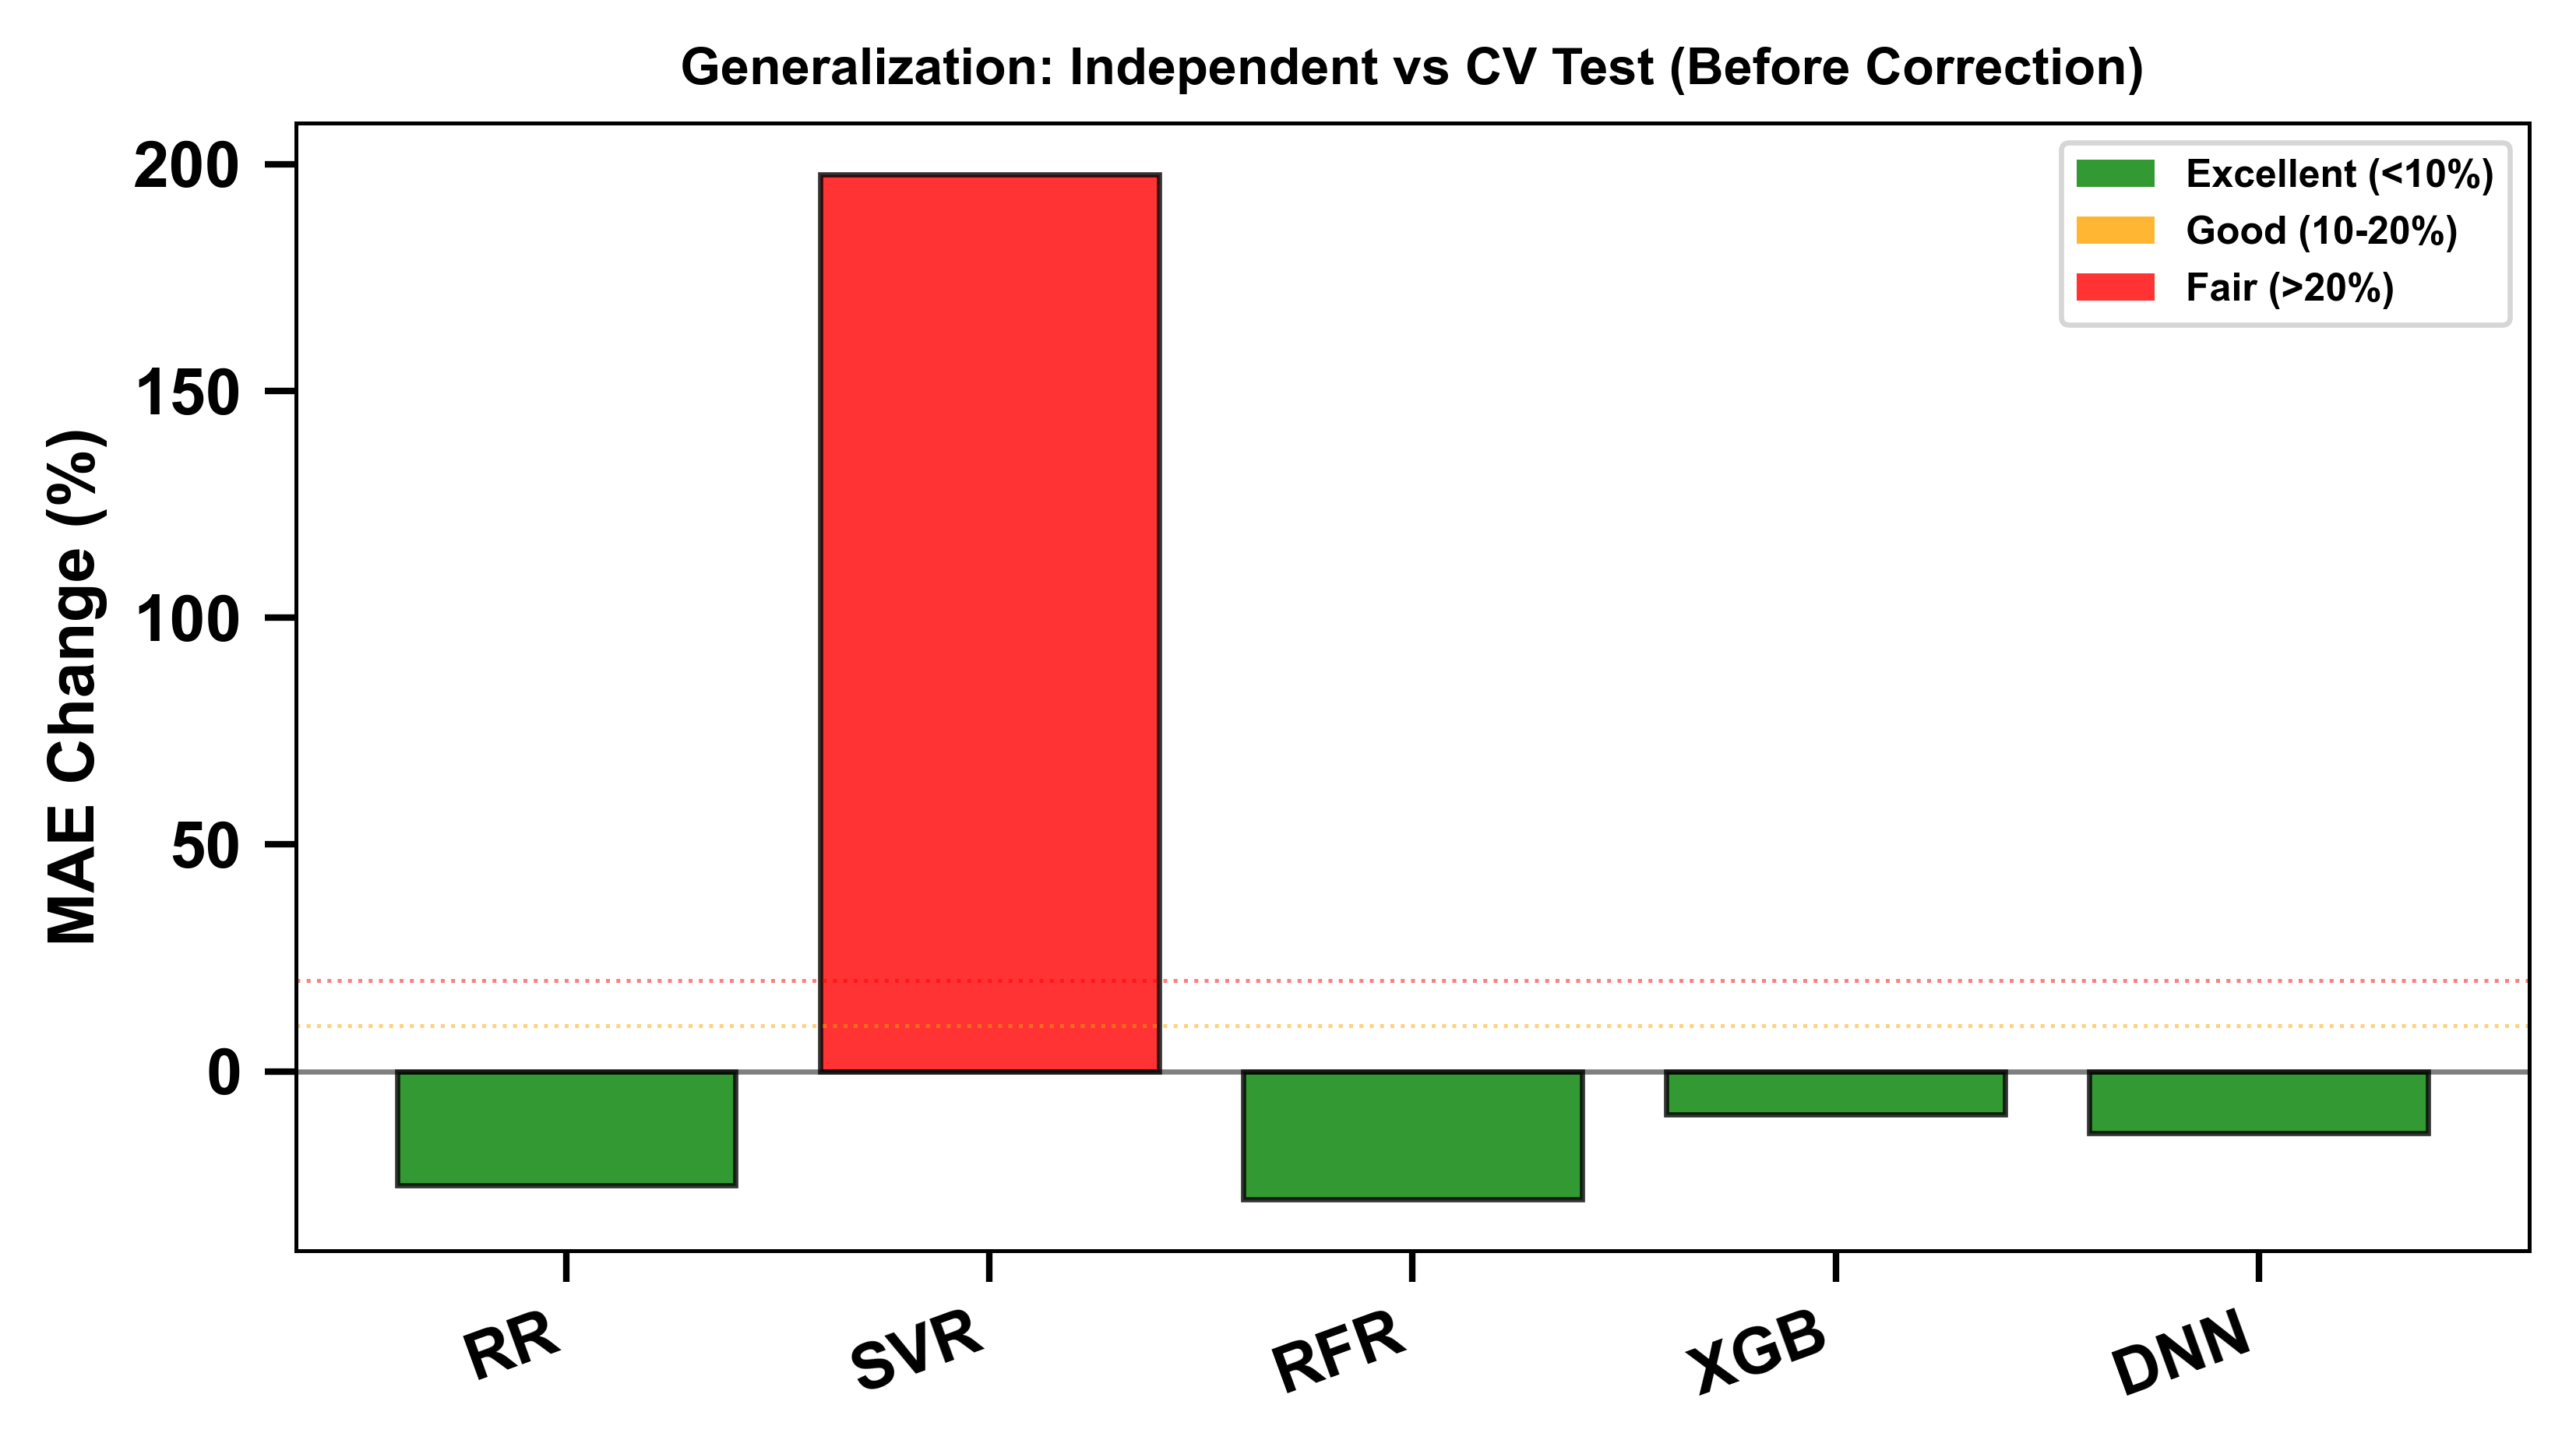

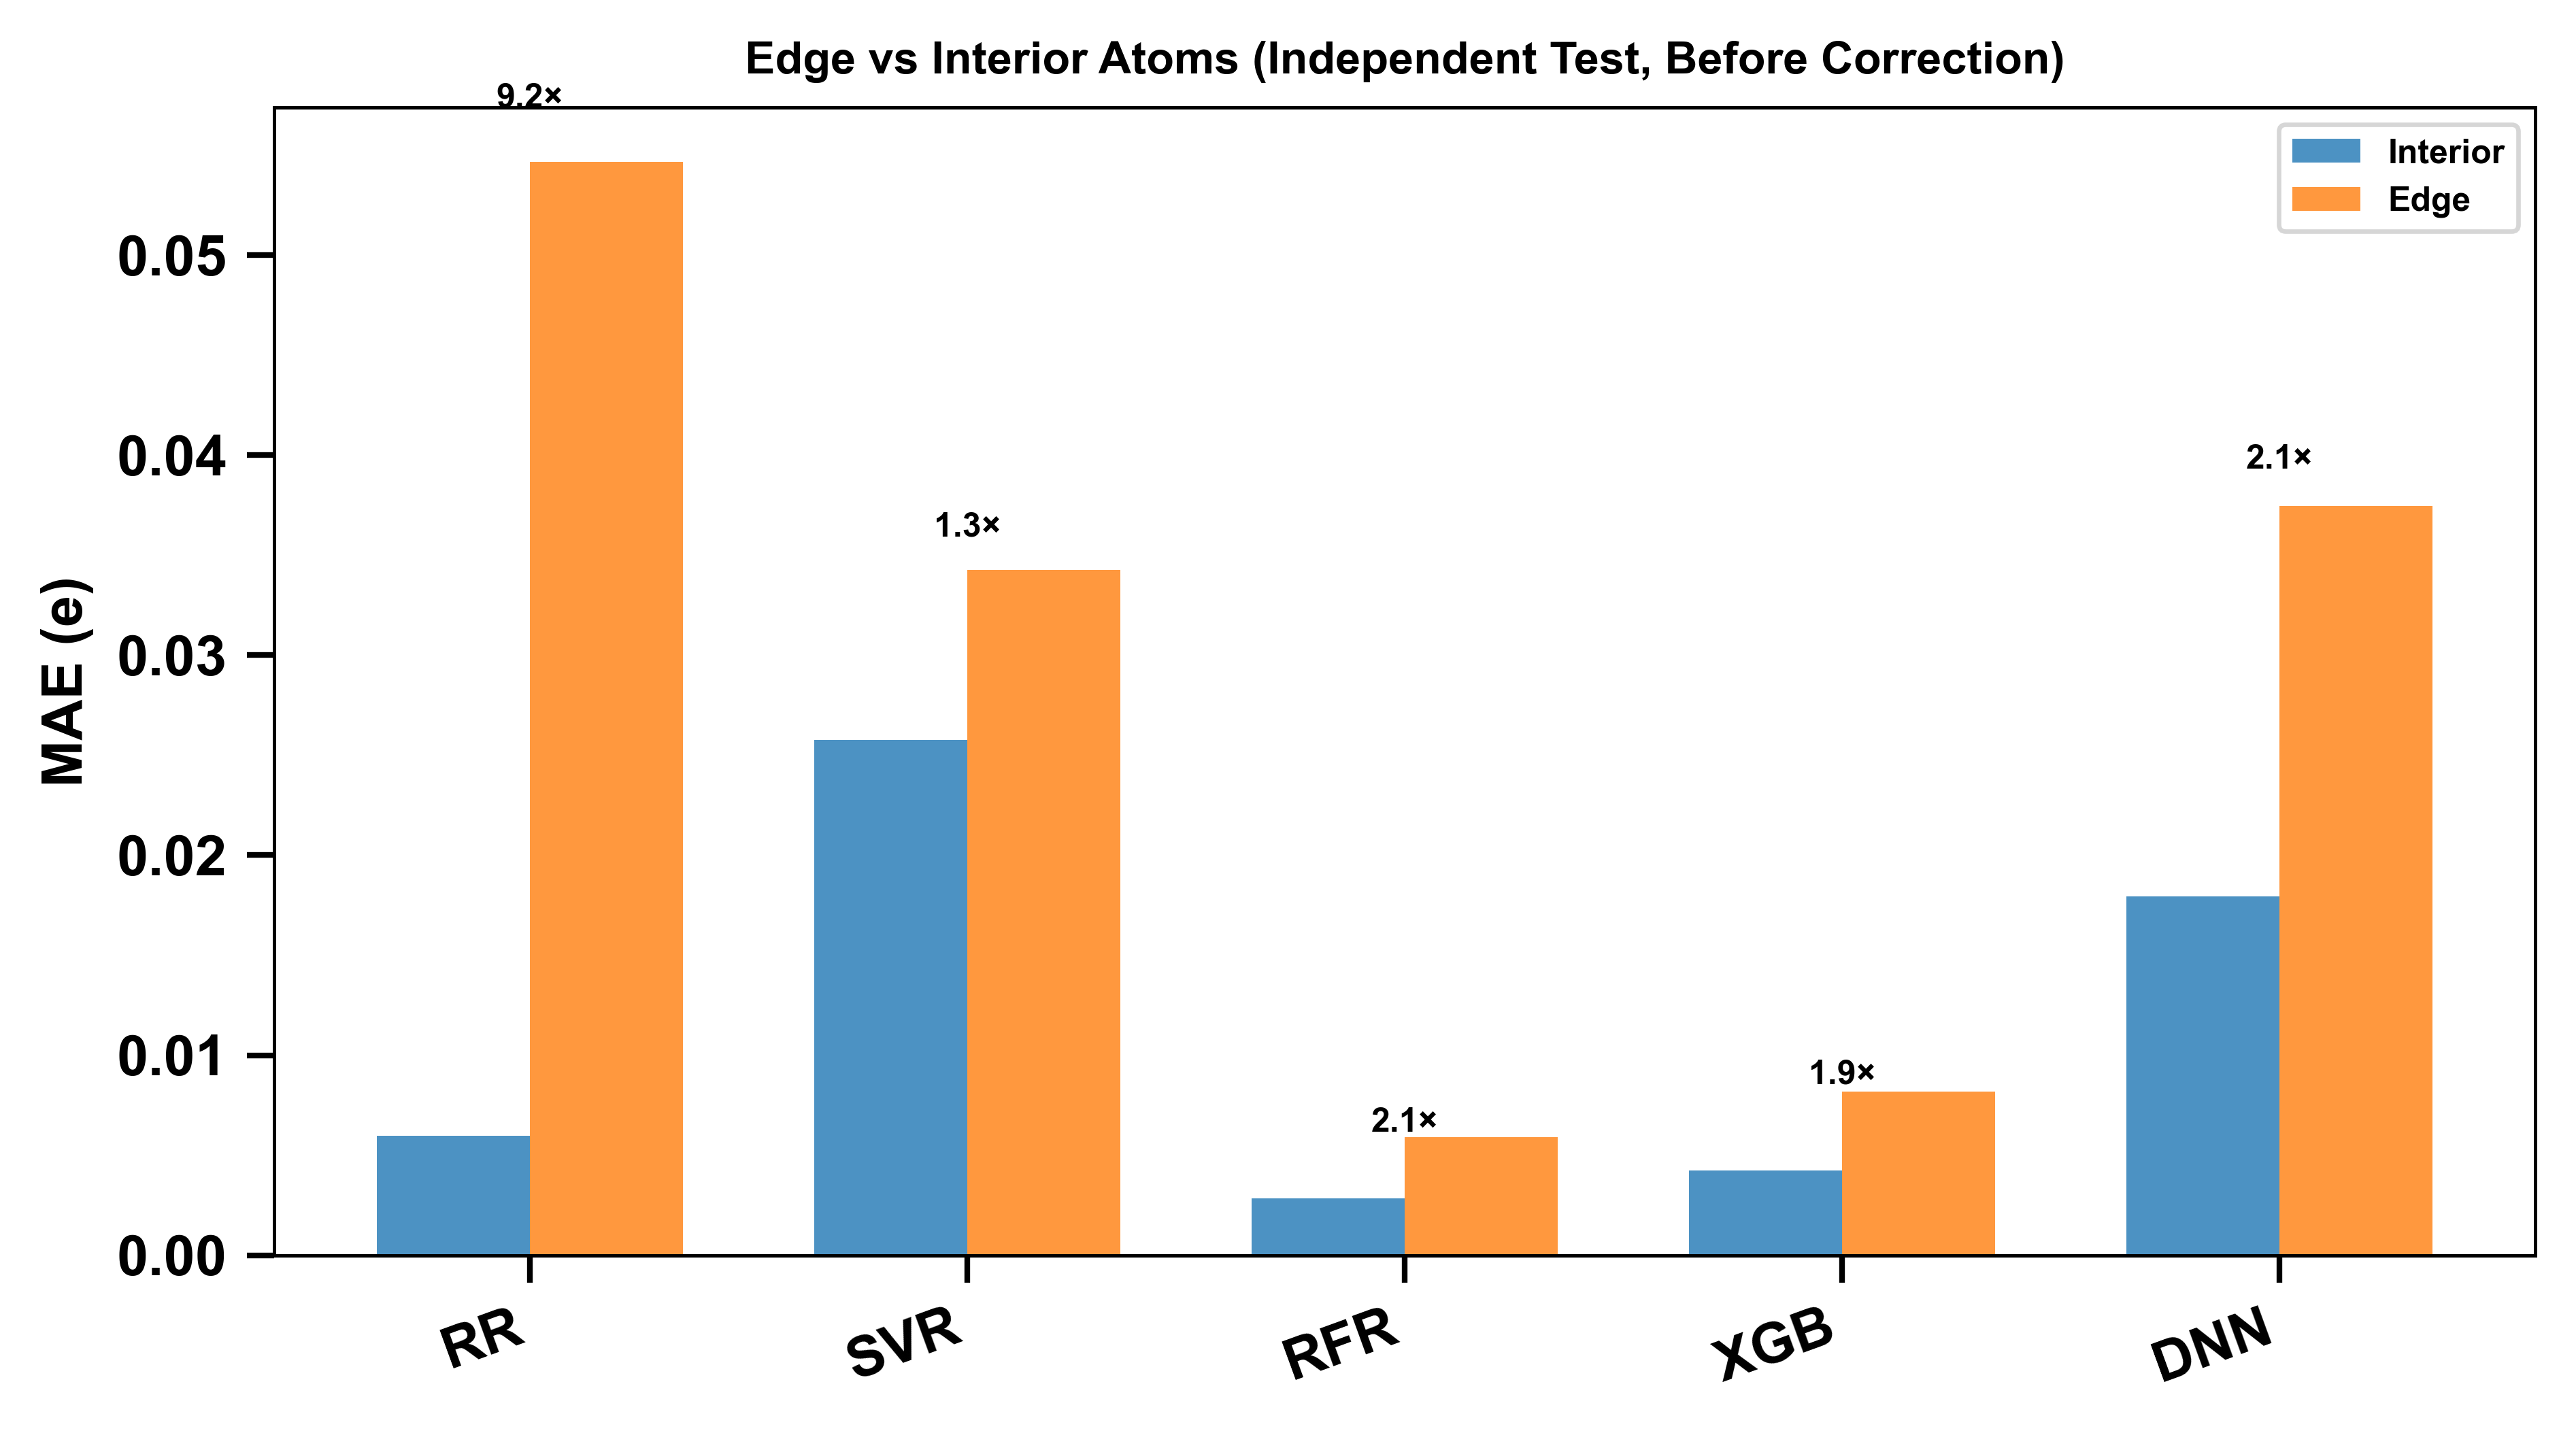

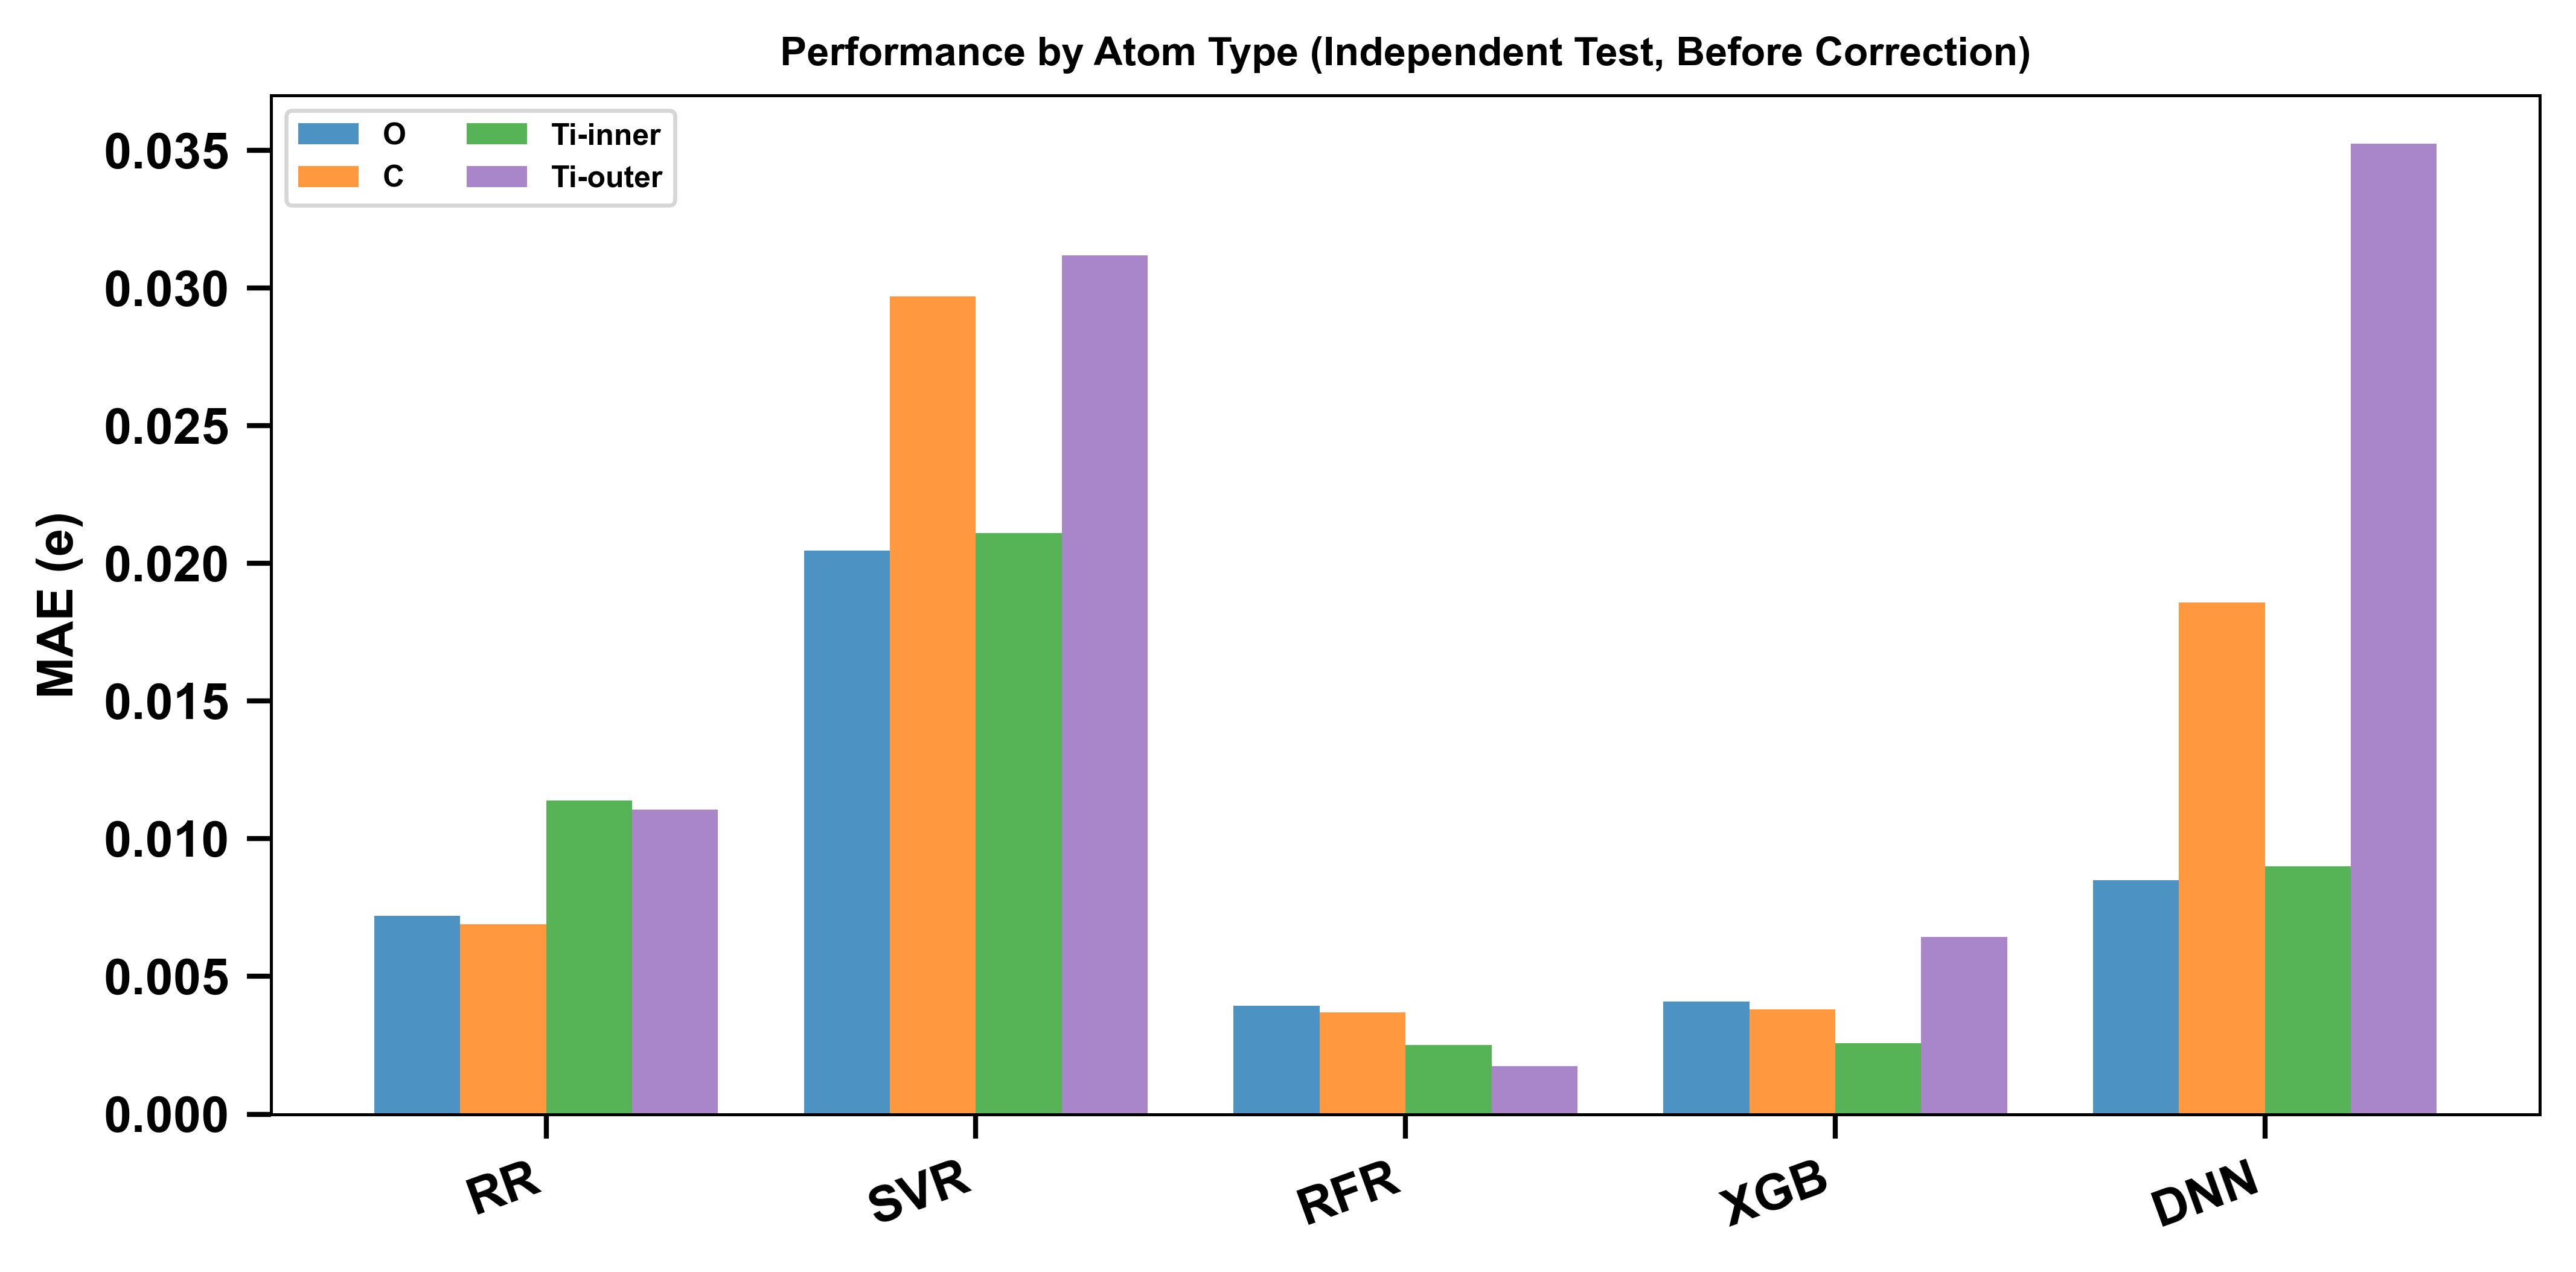

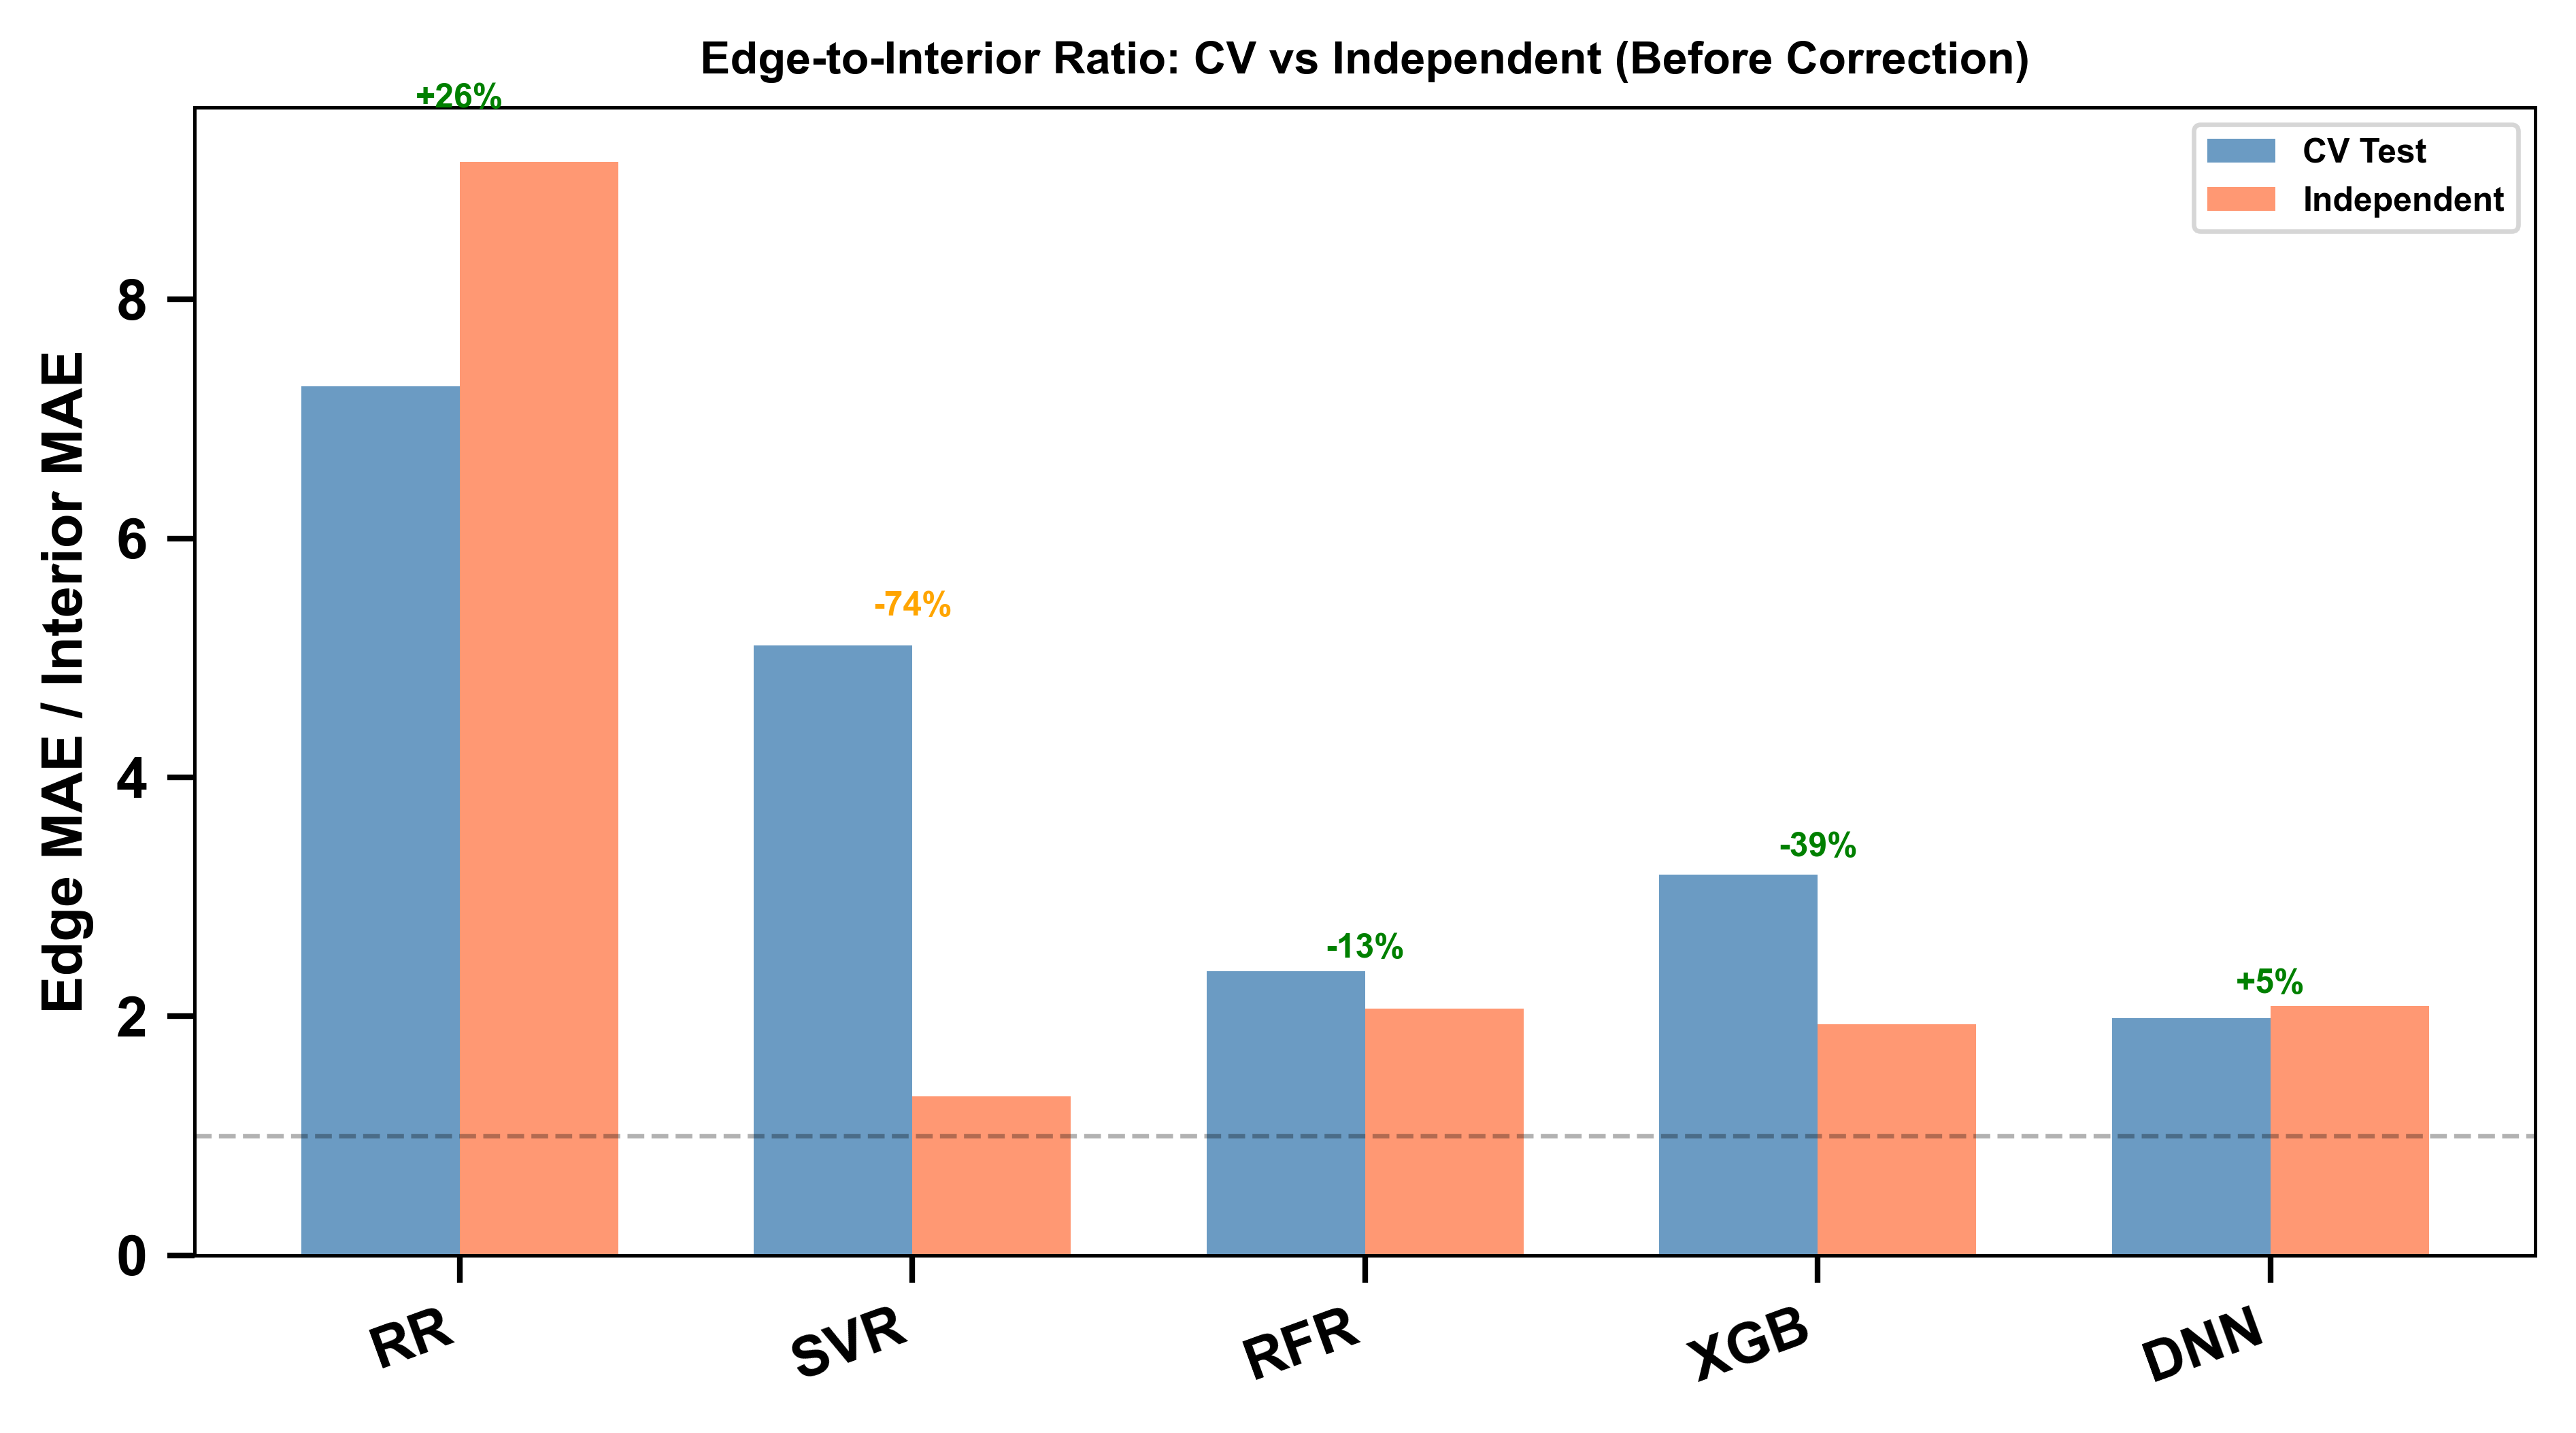

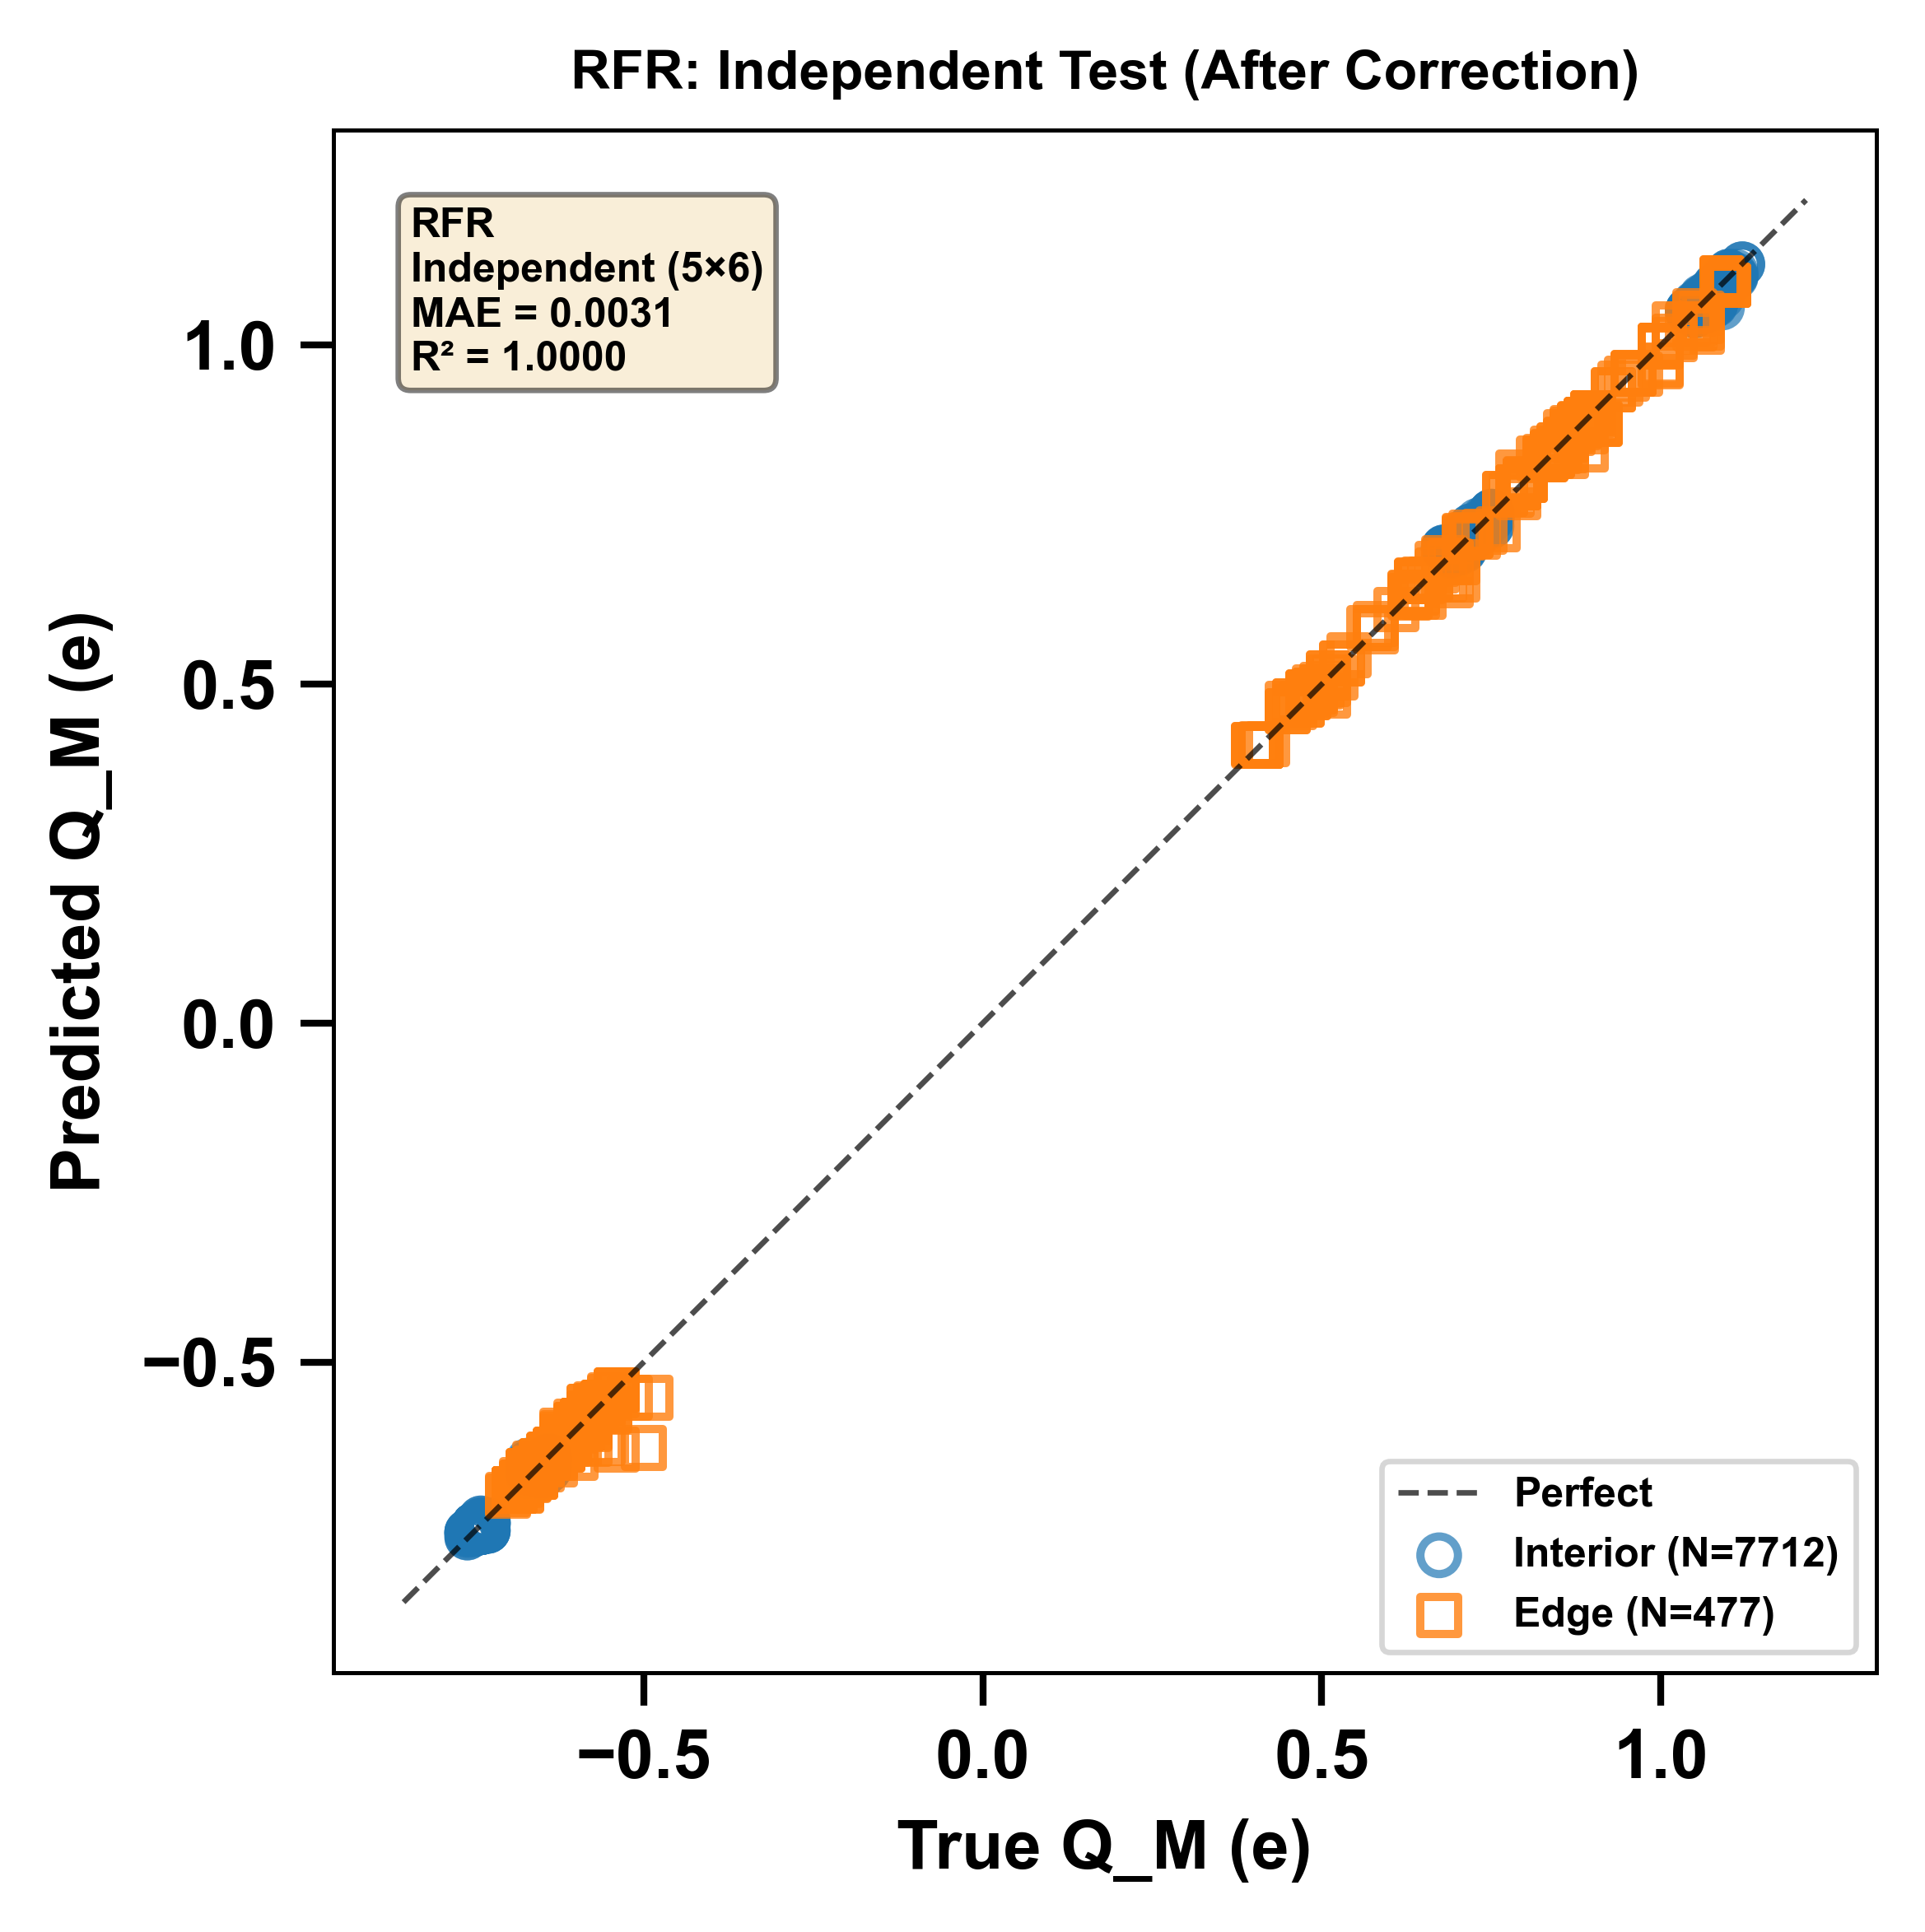

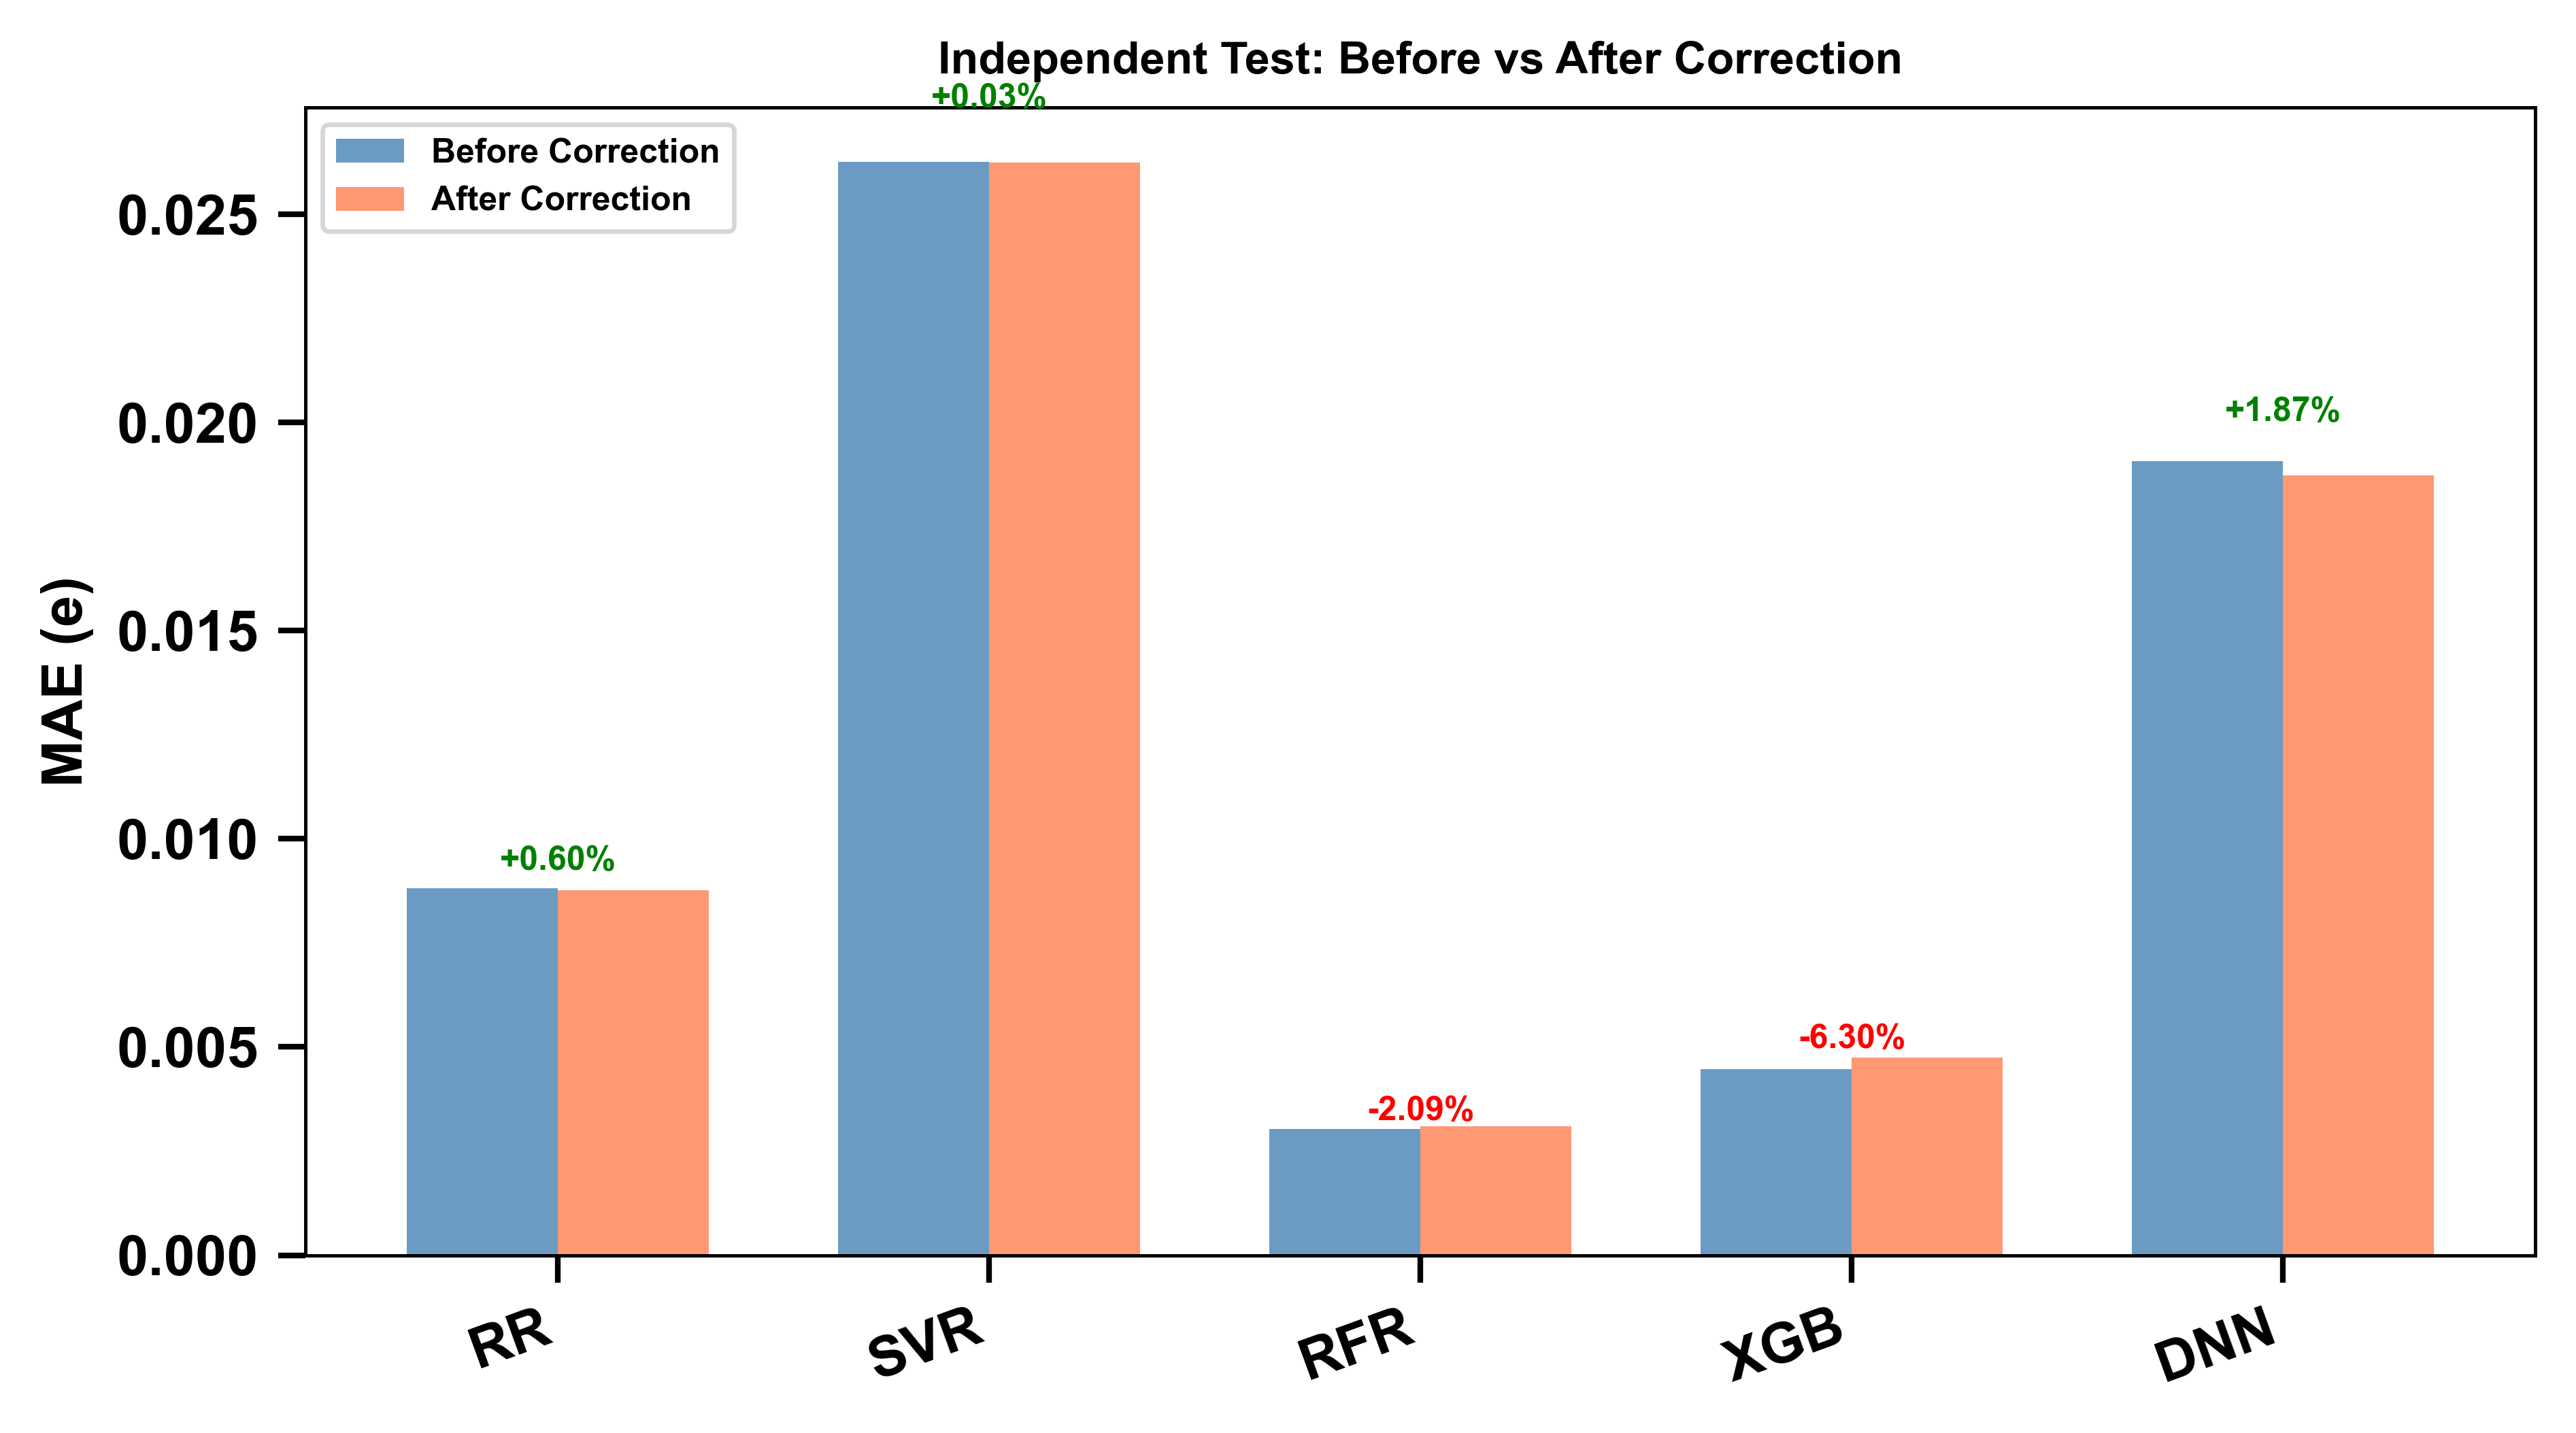

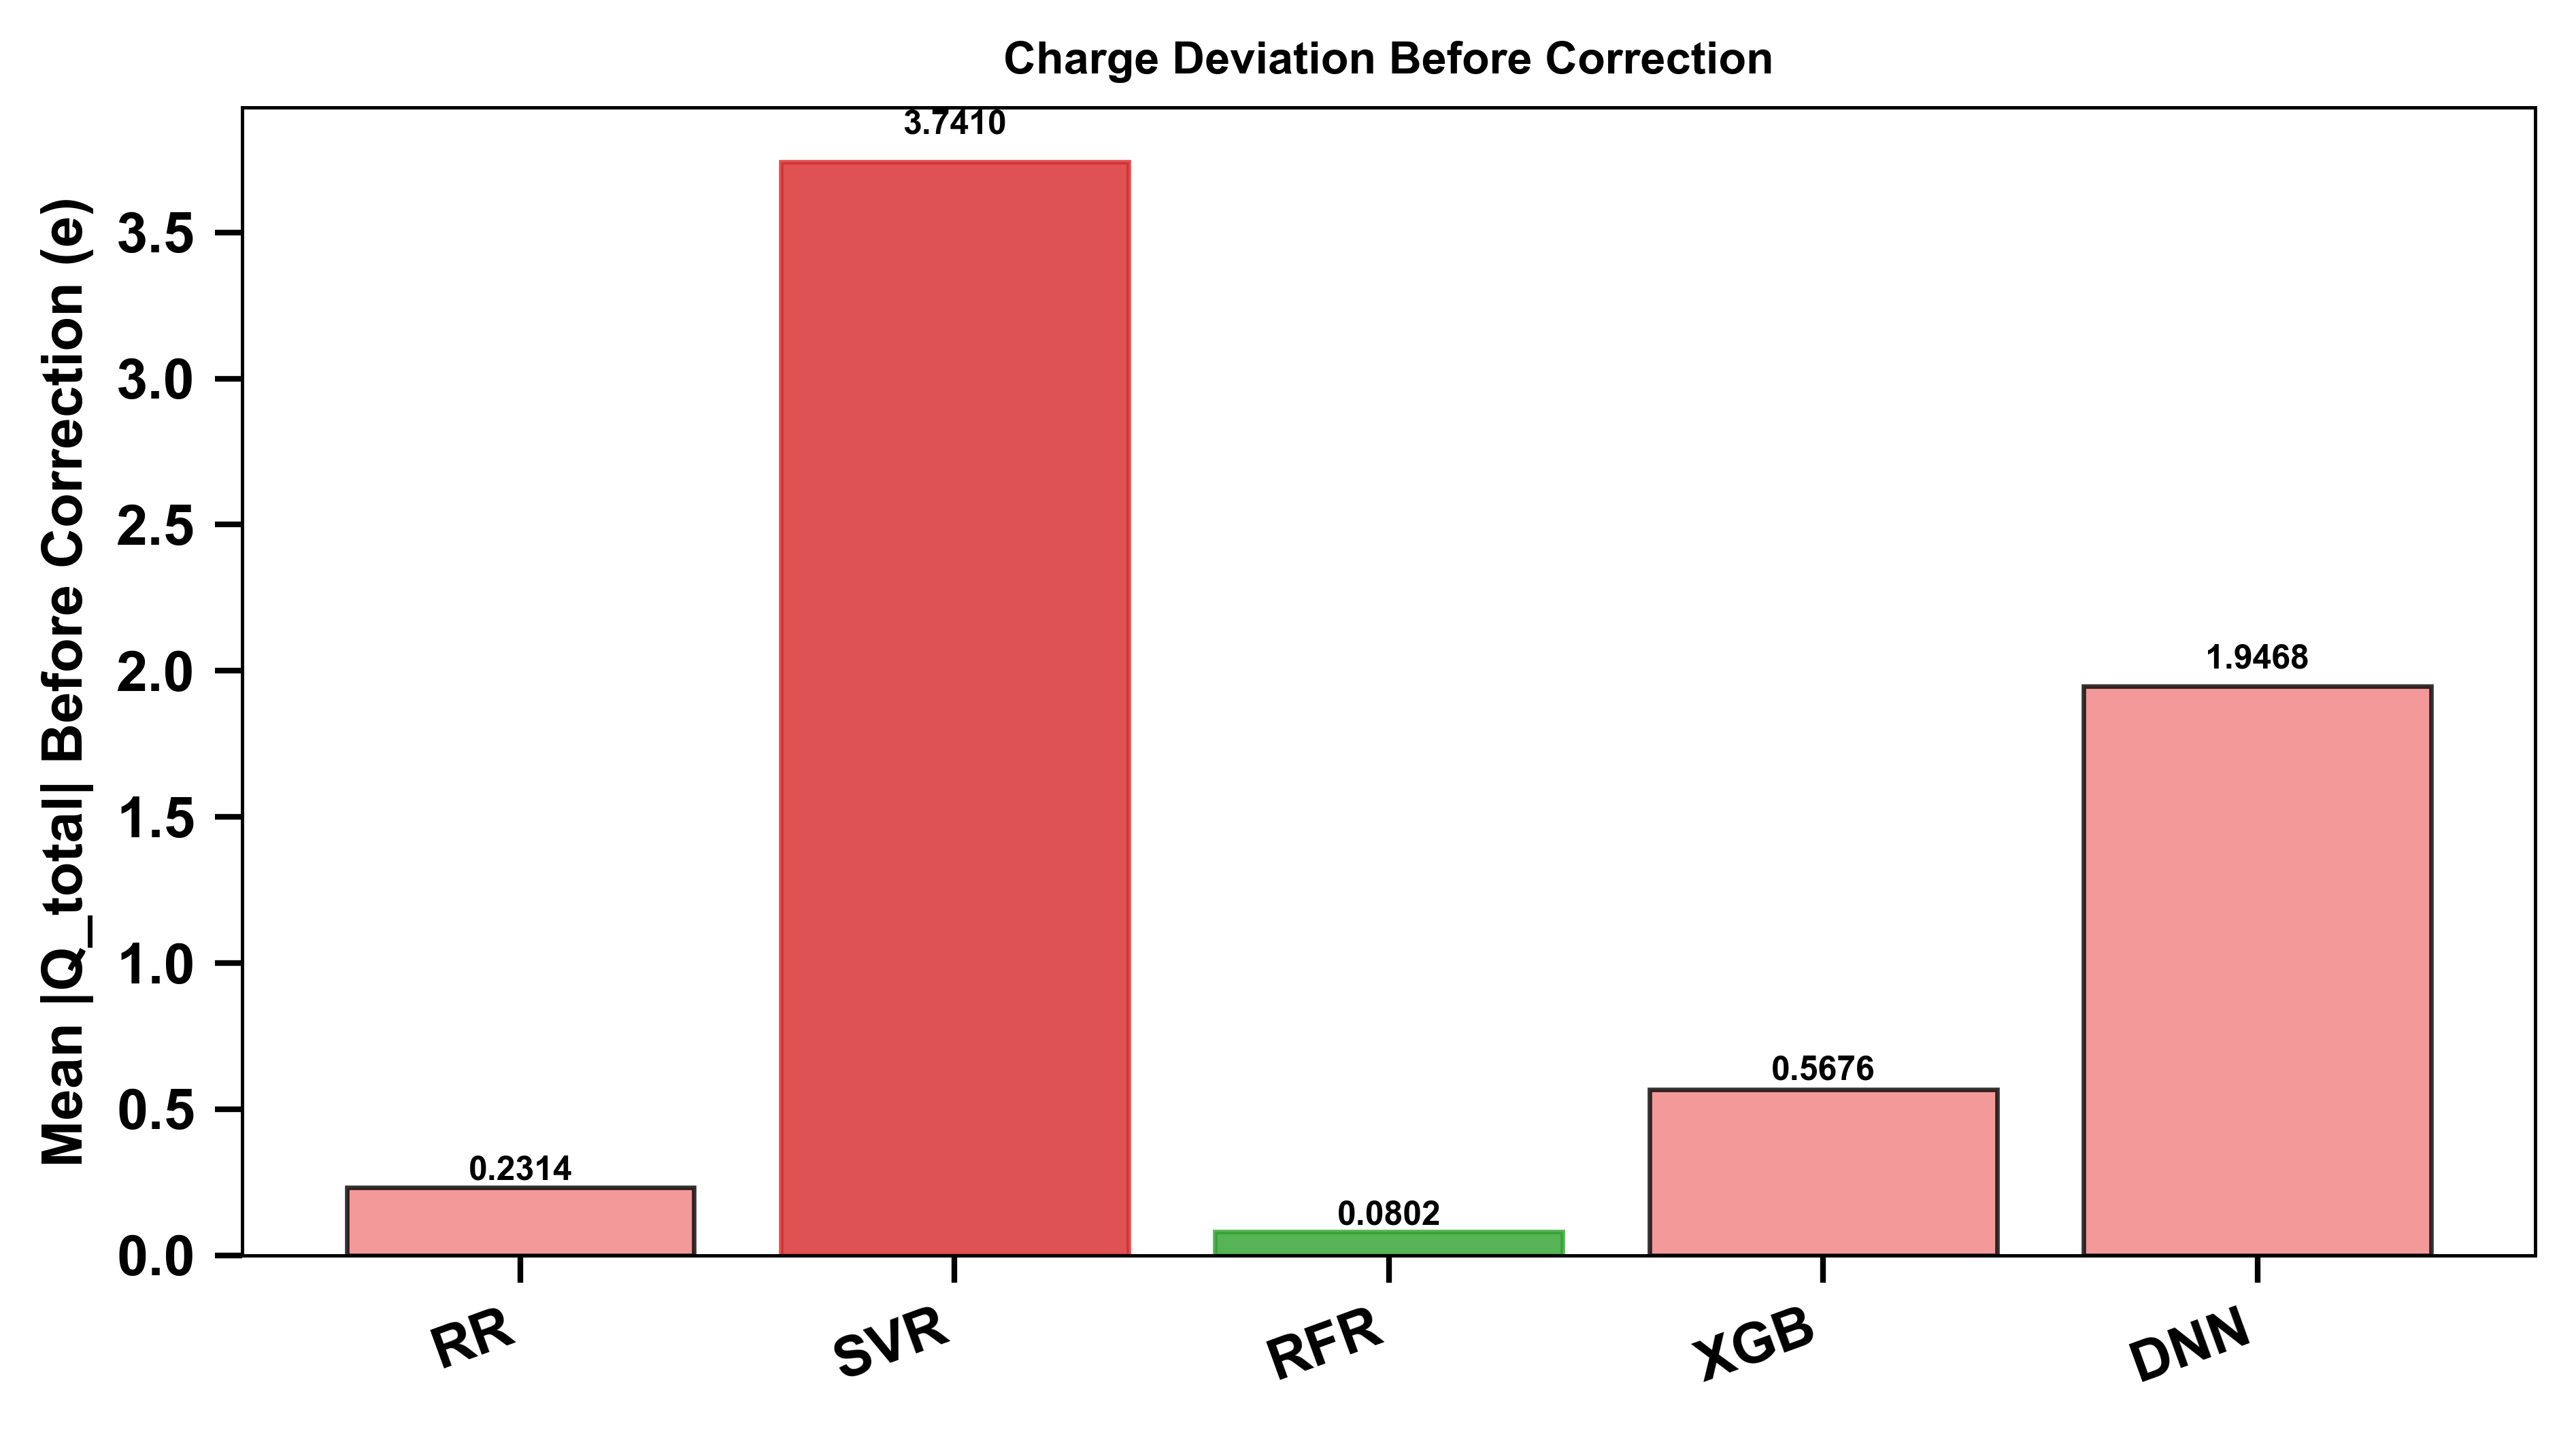

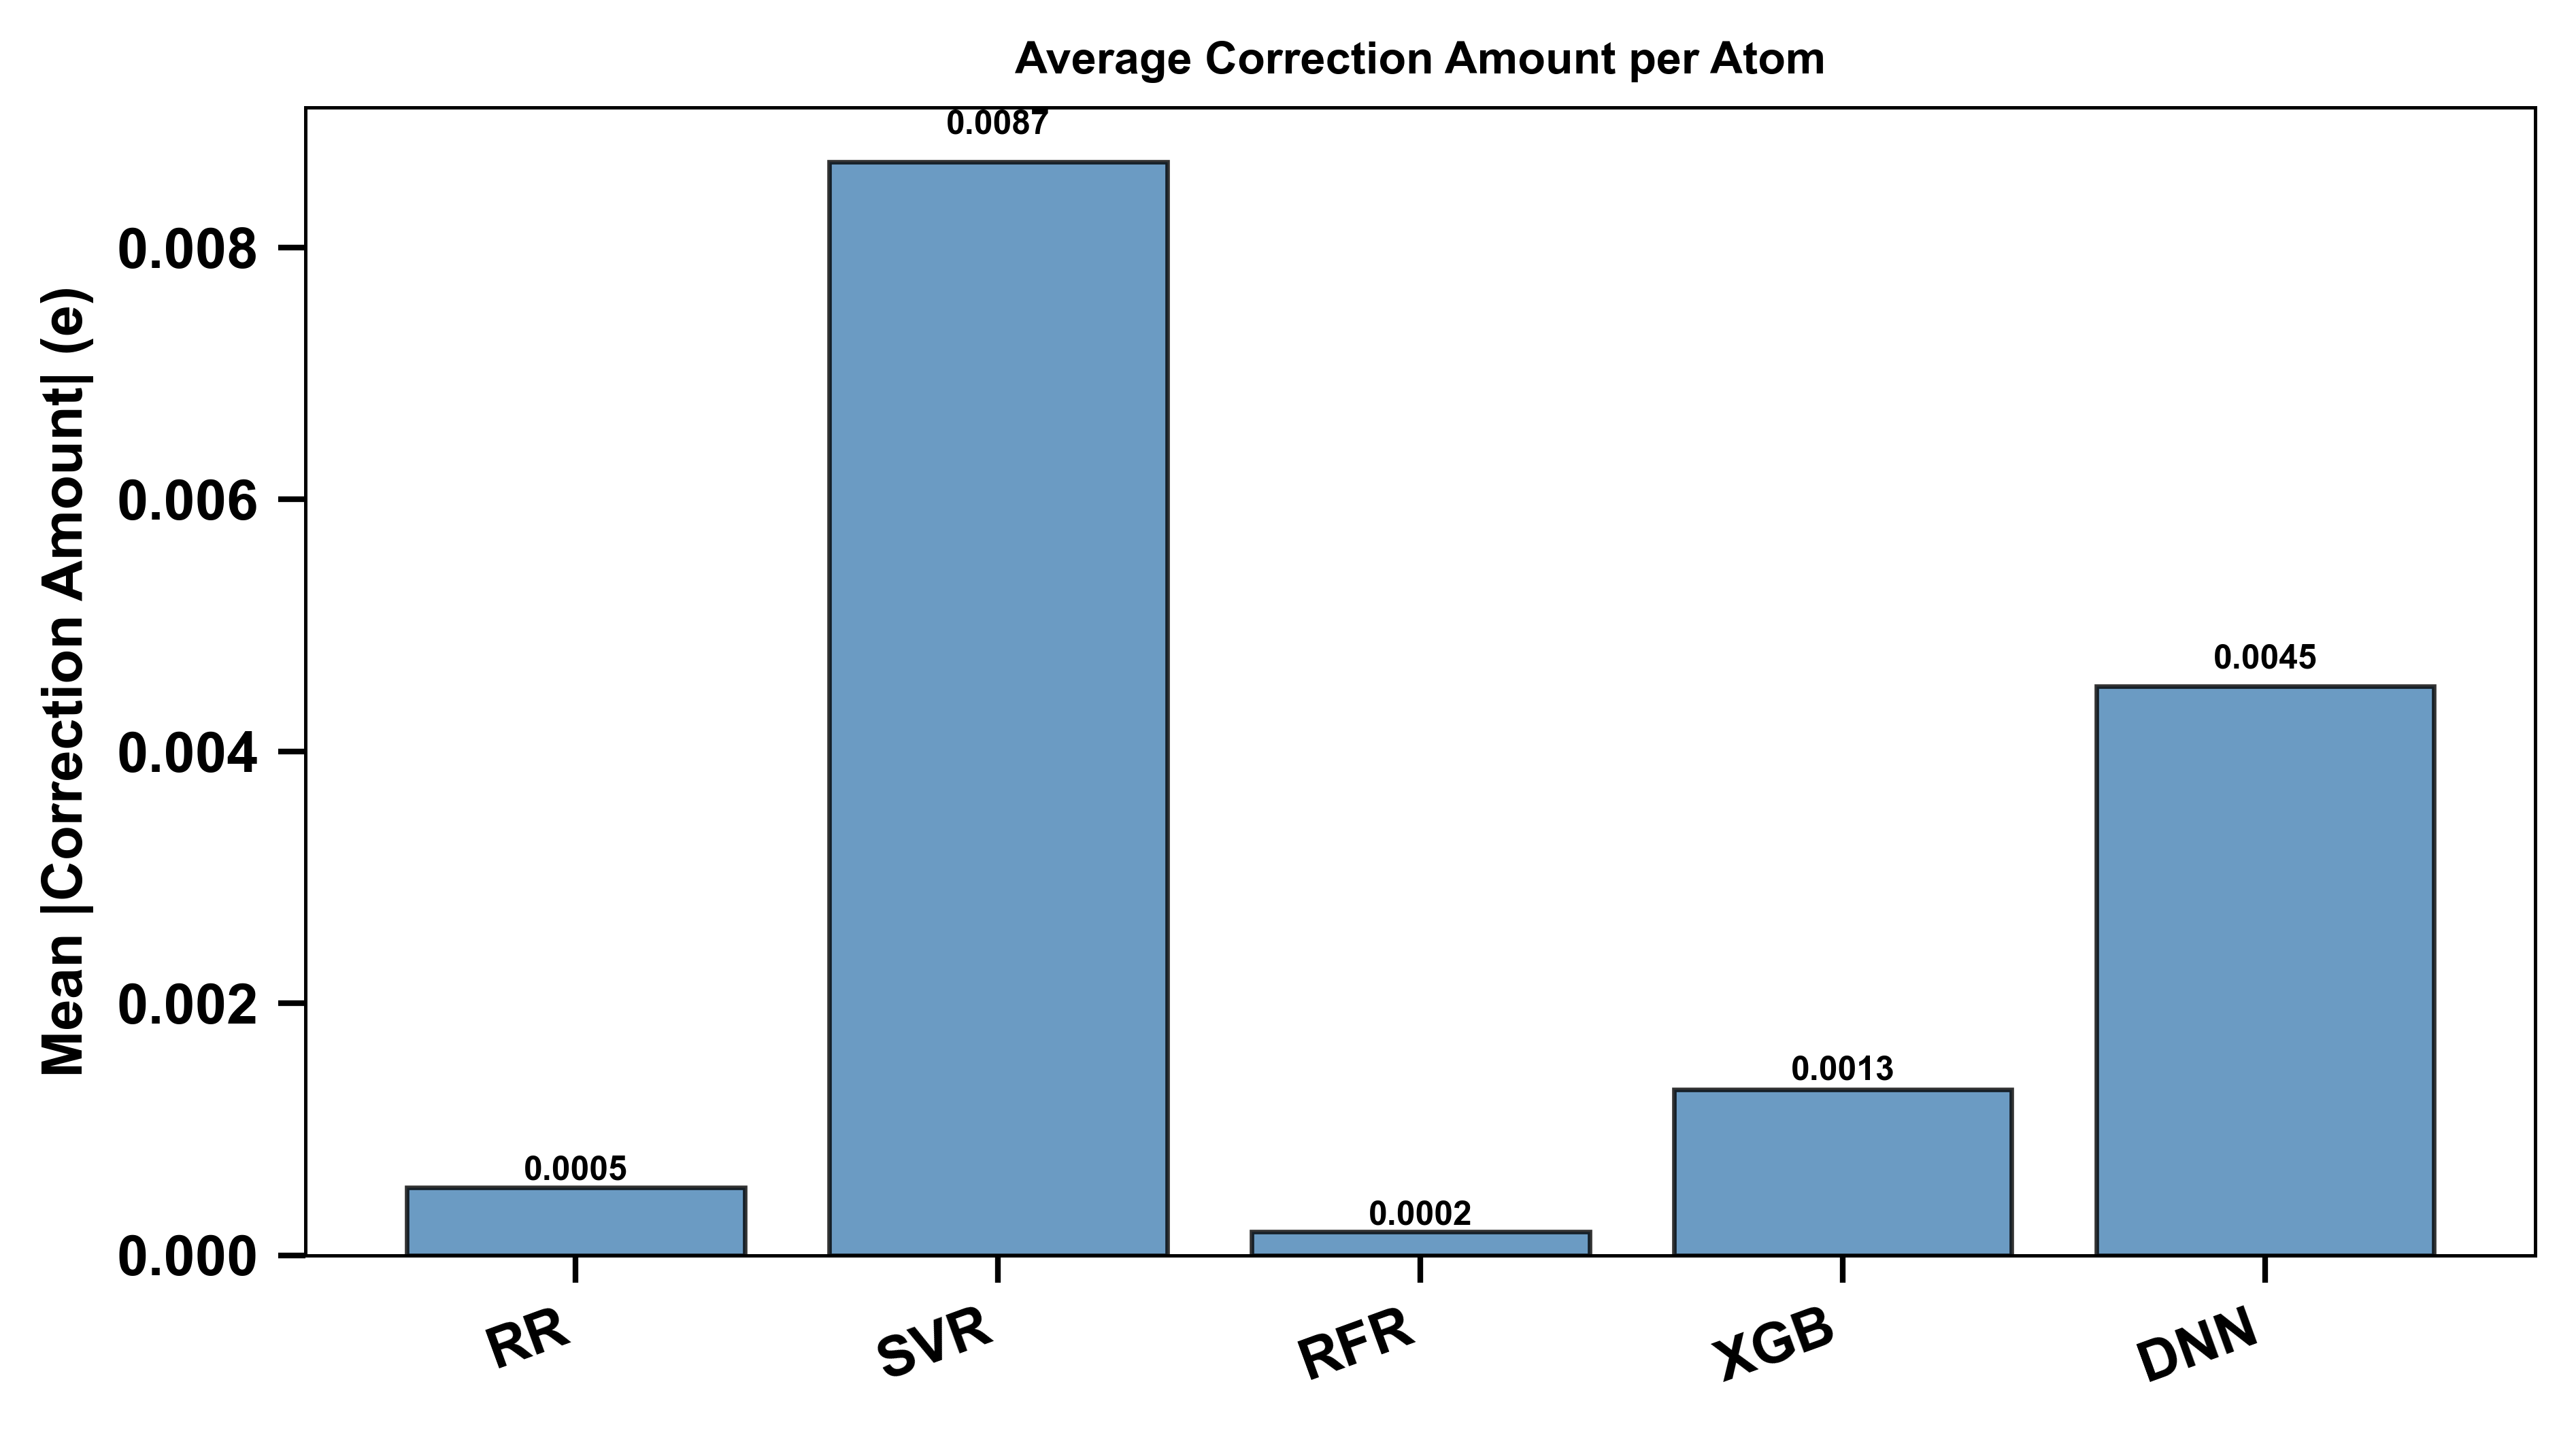

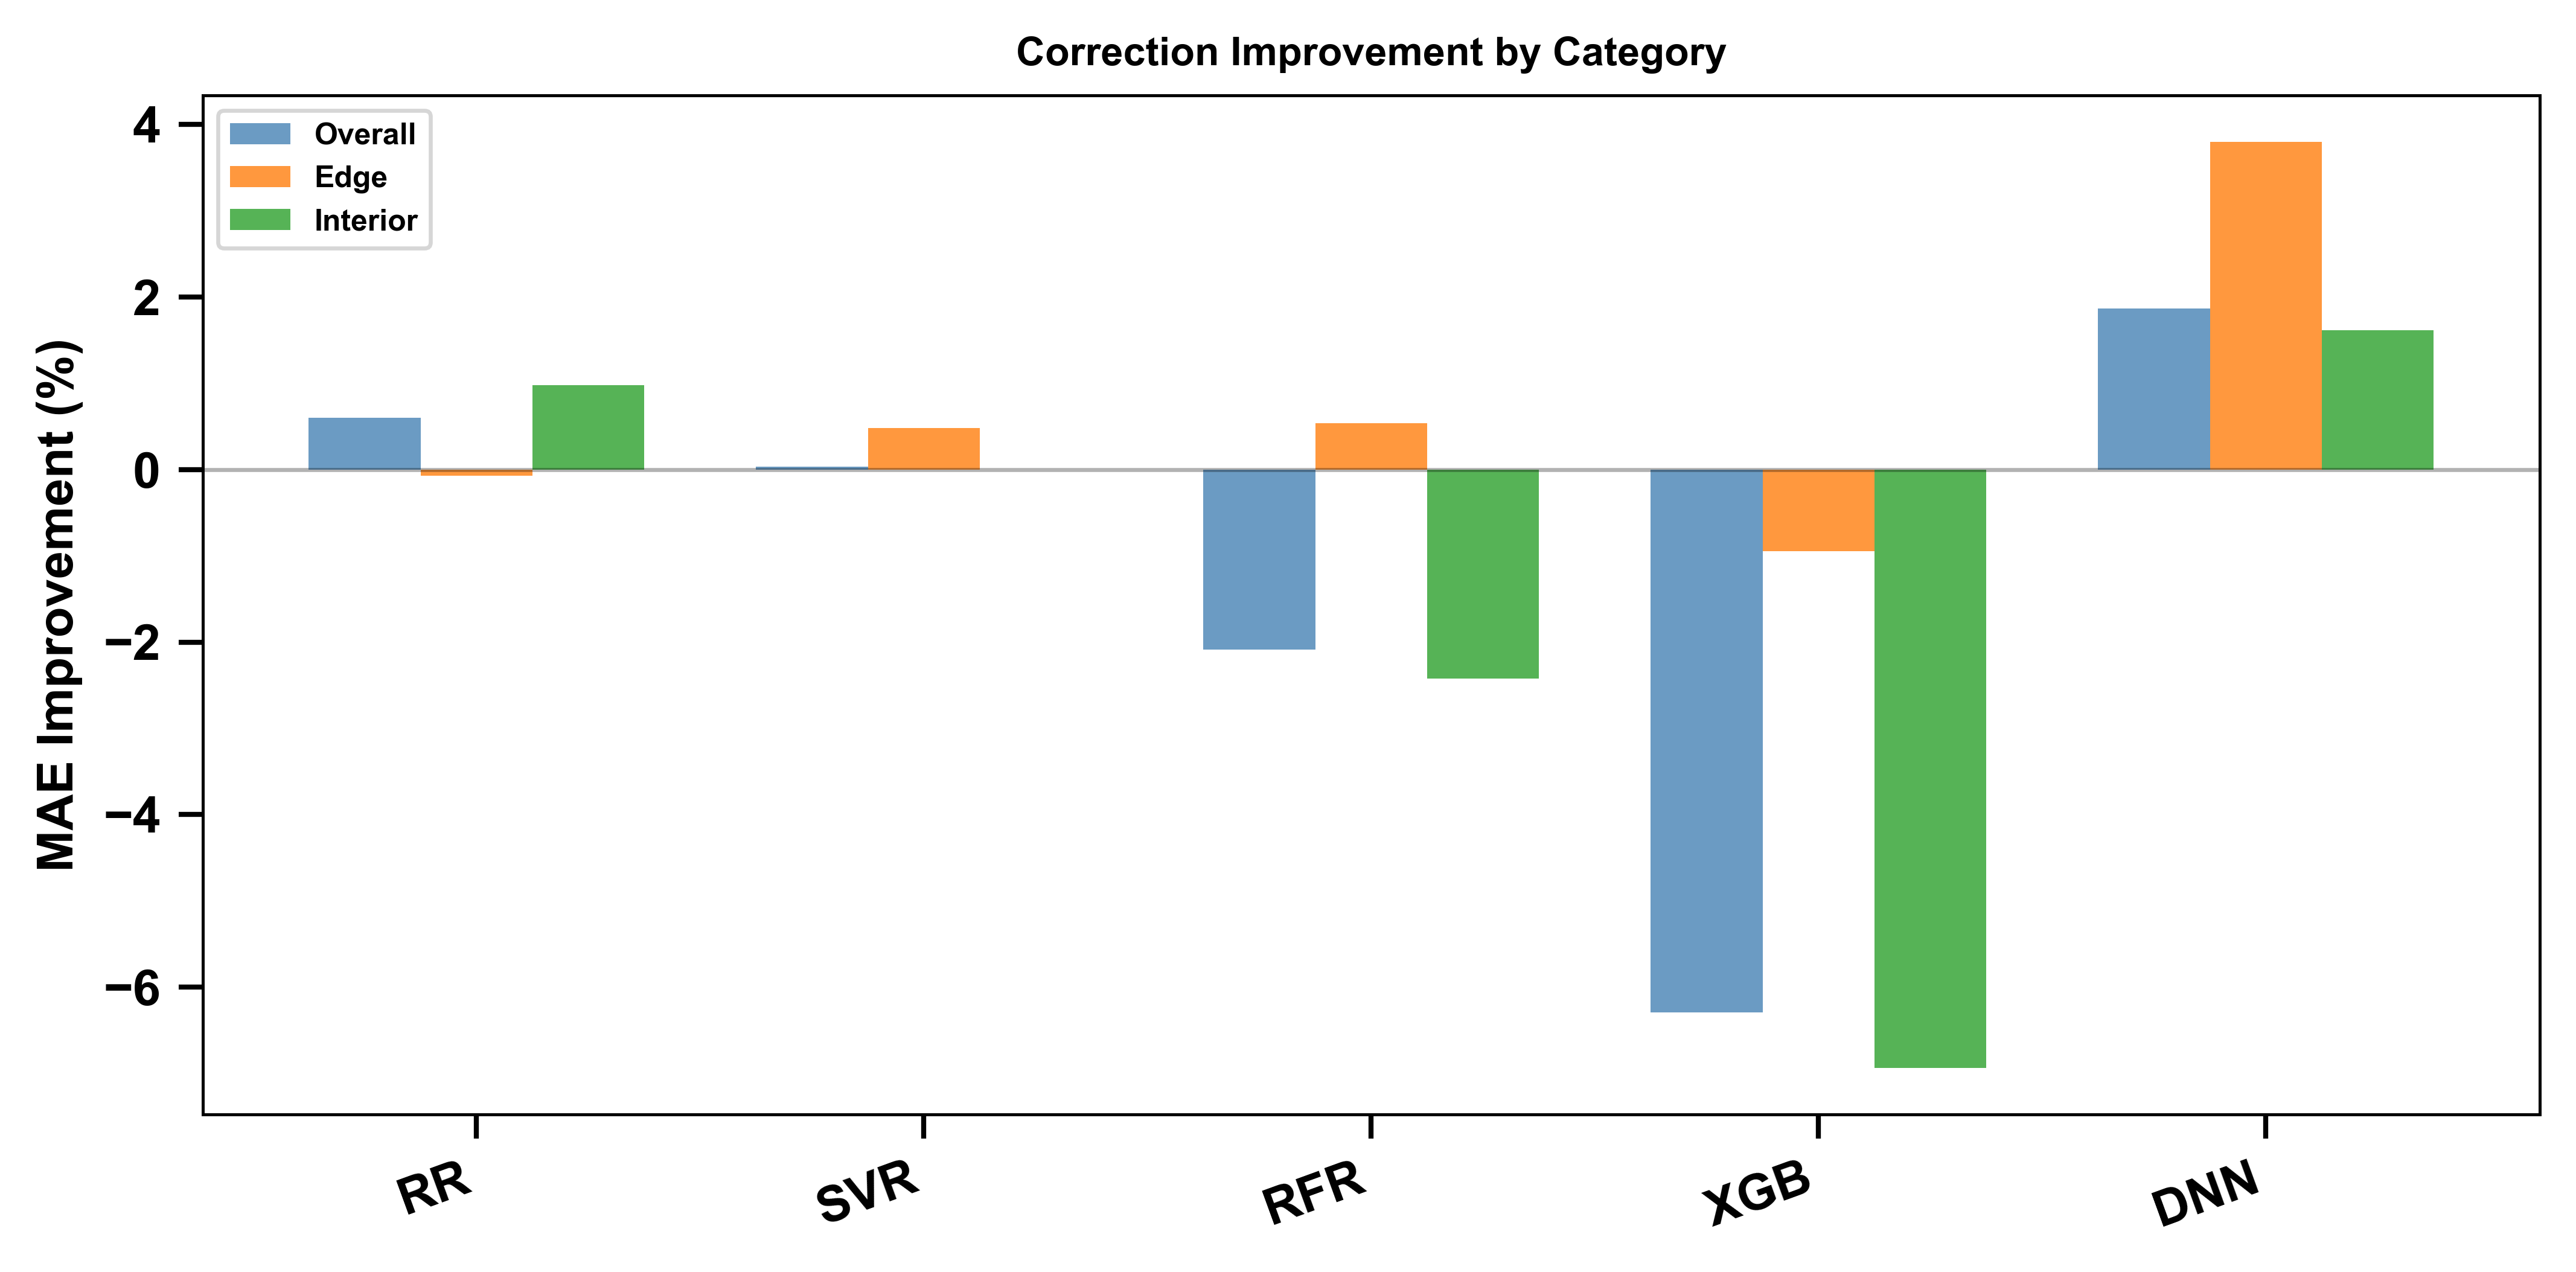

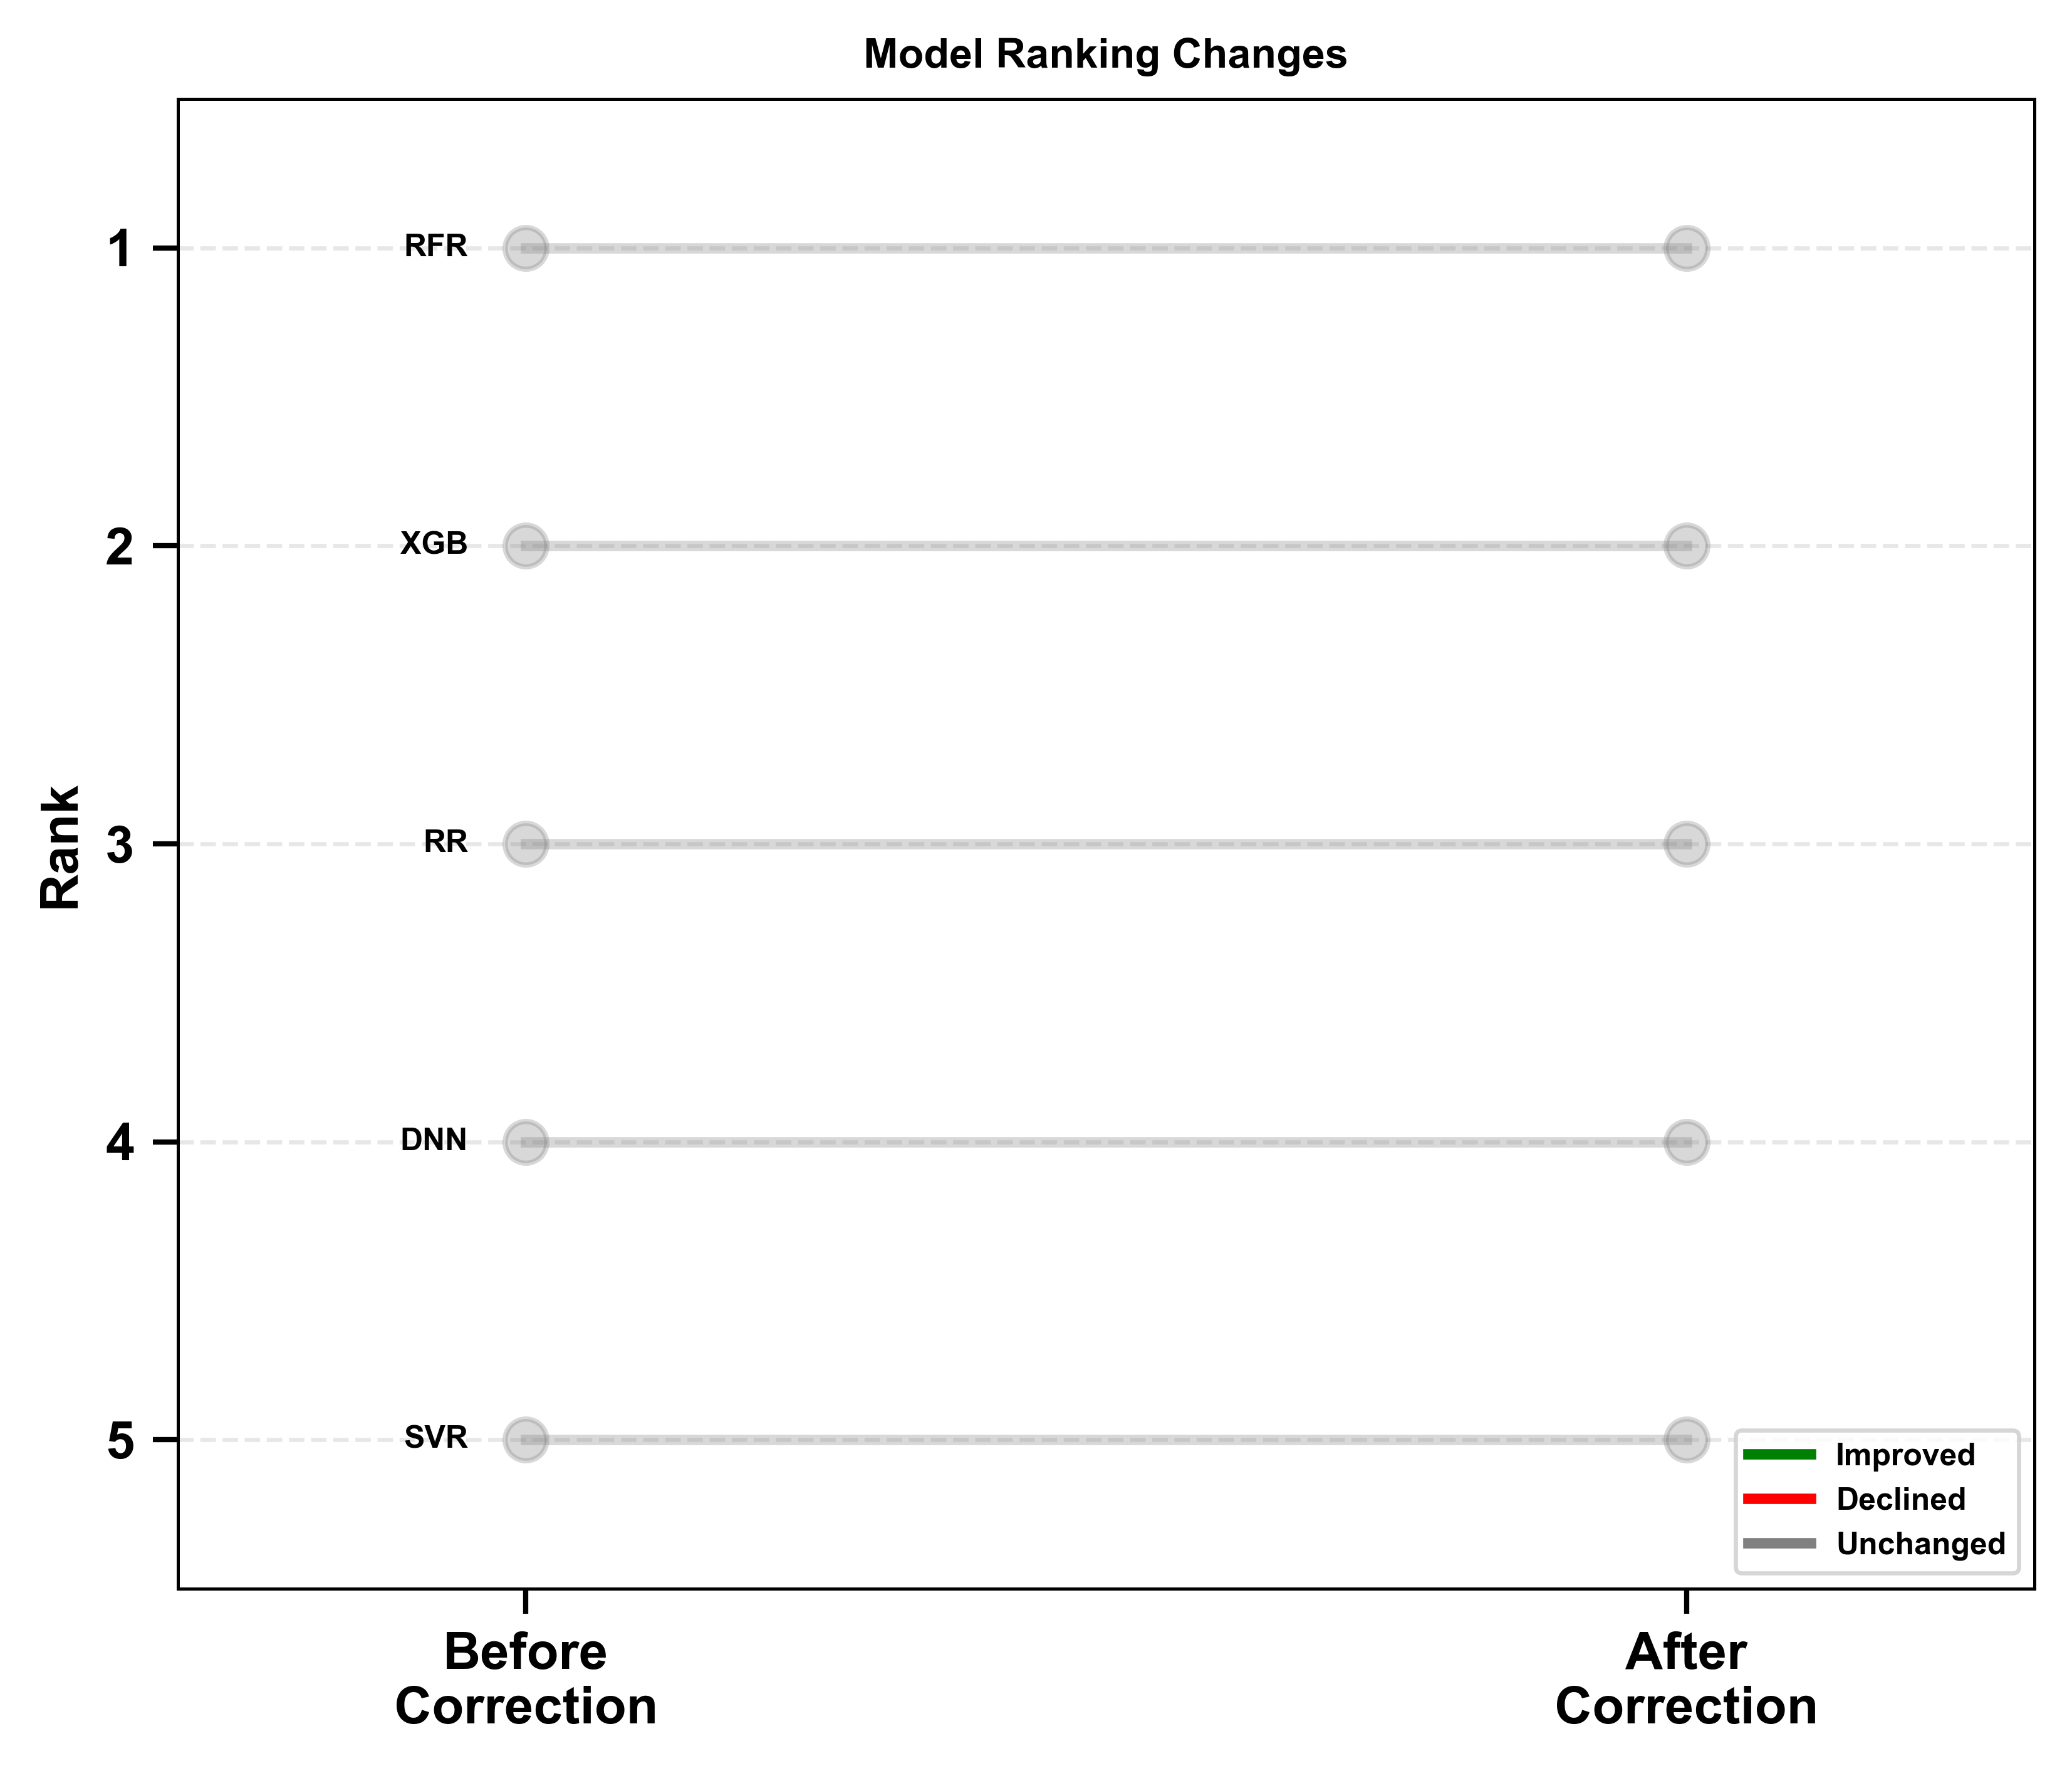

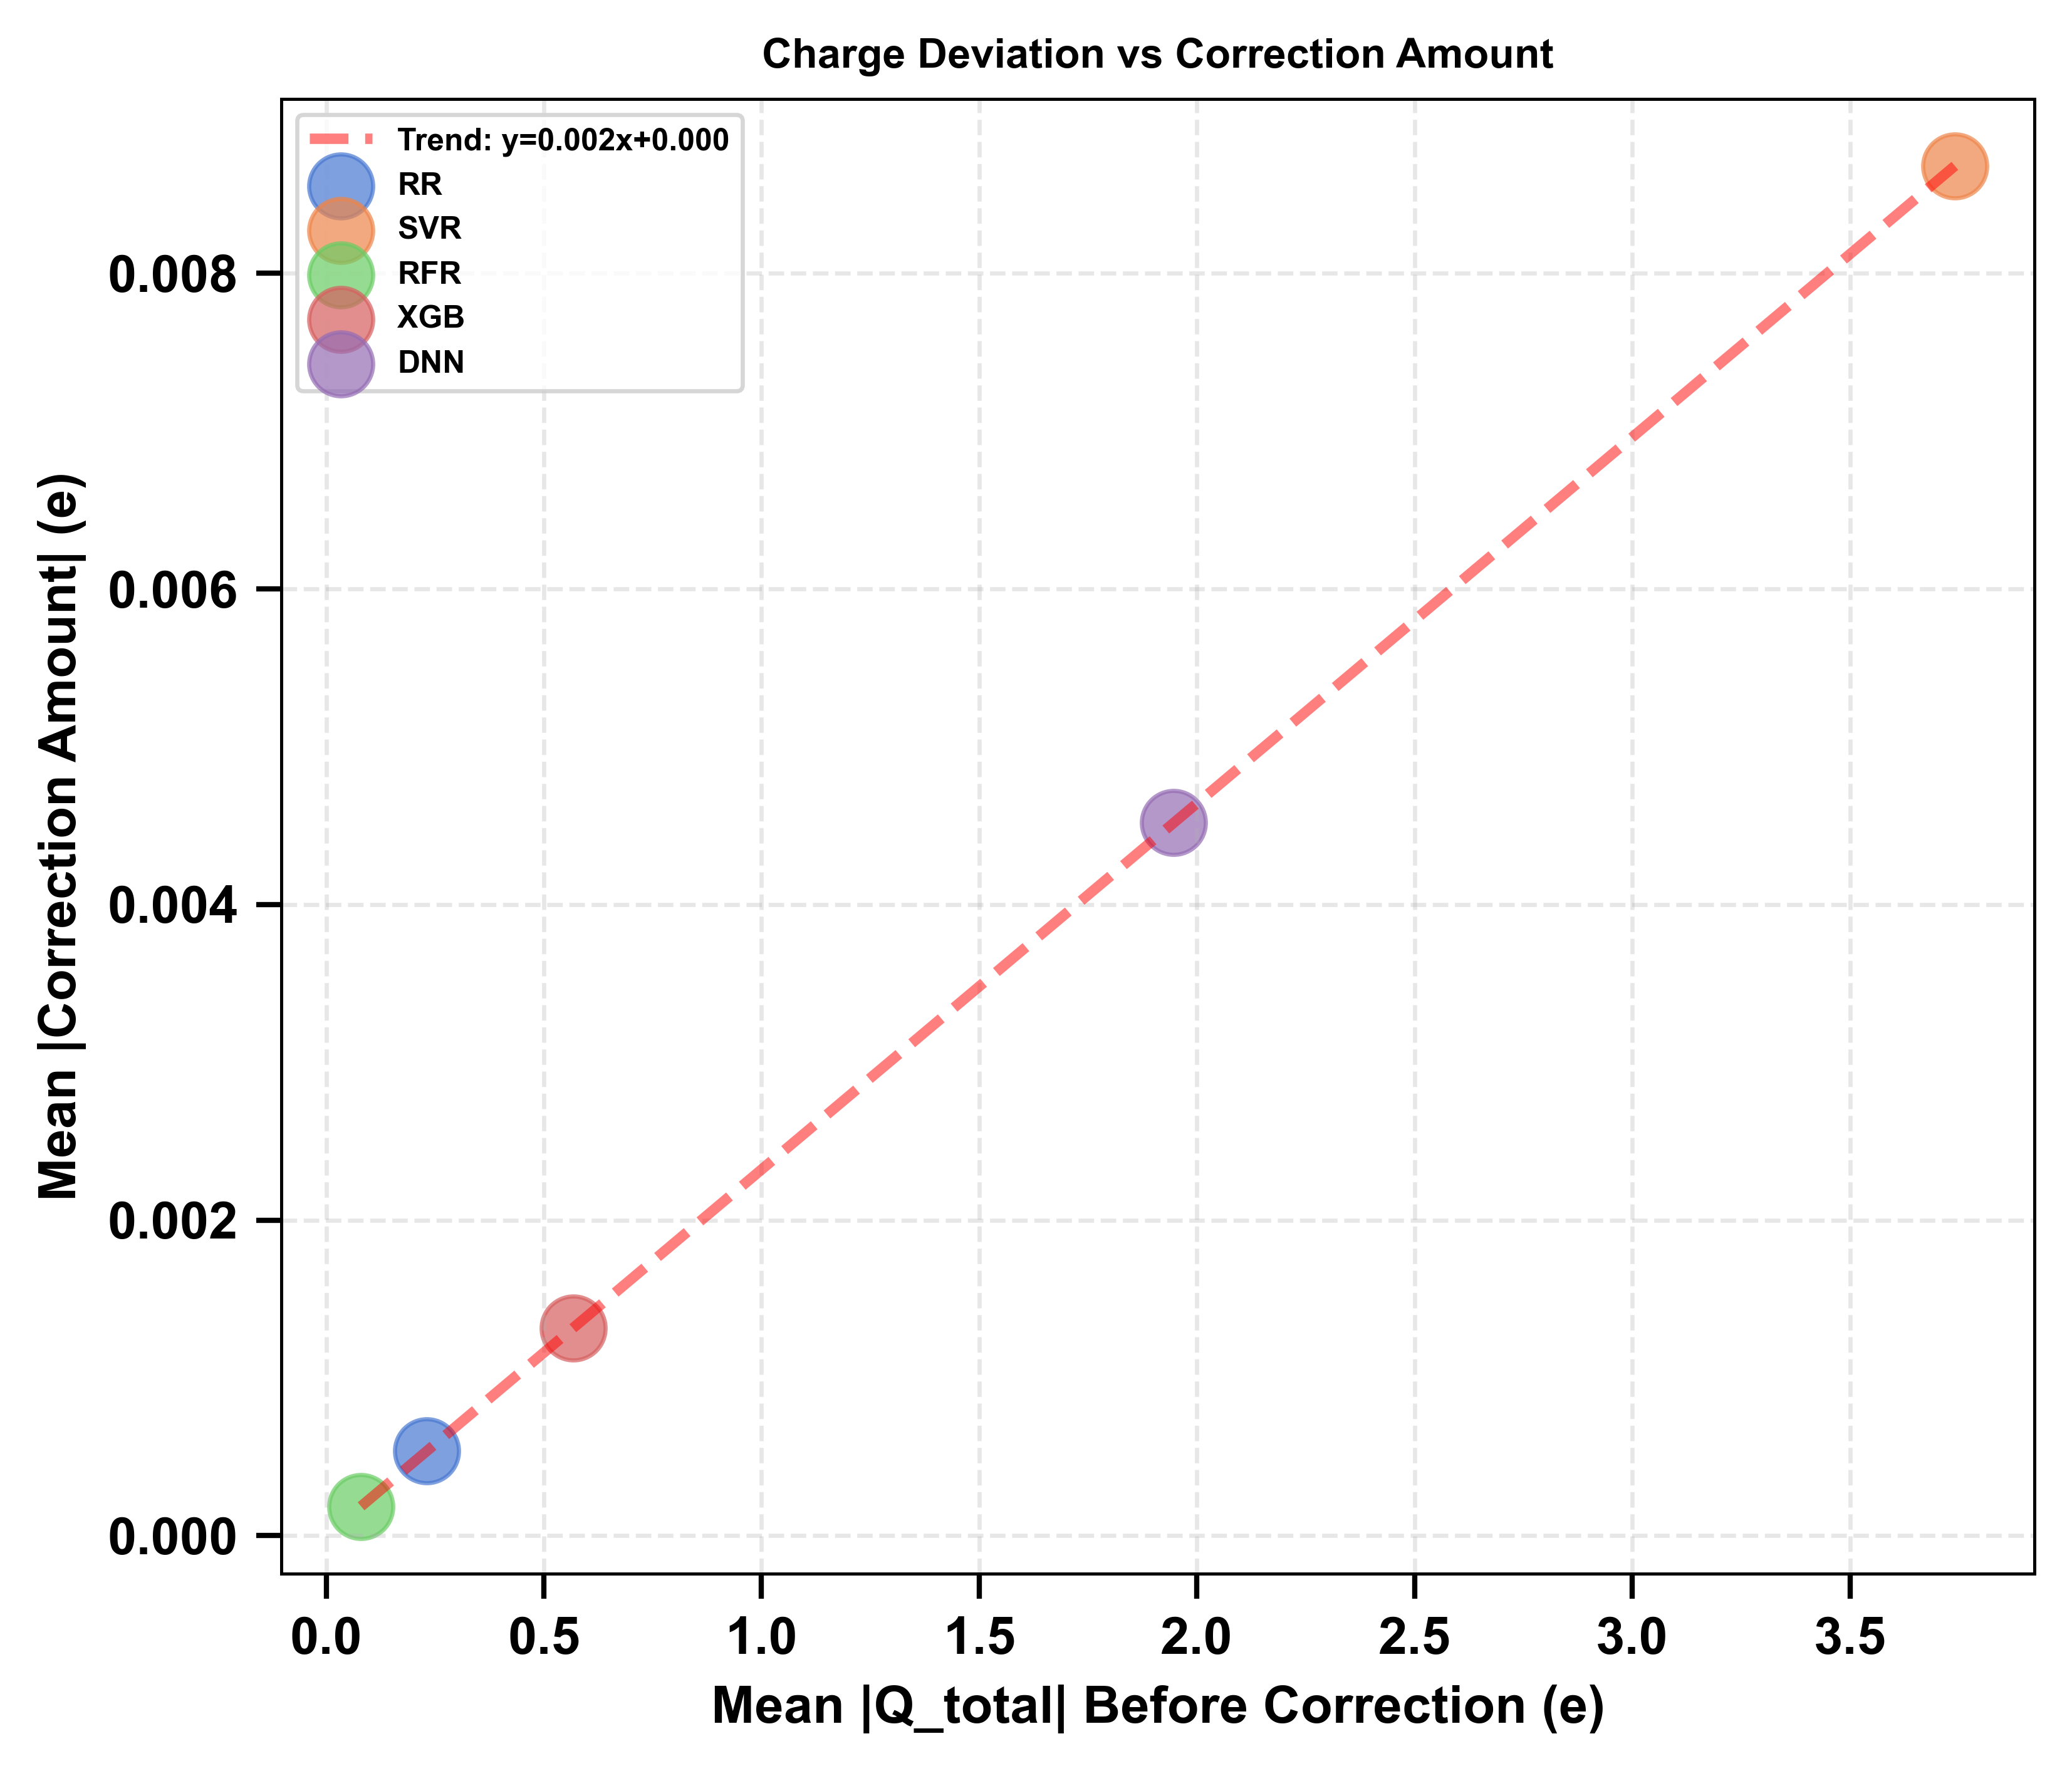

In [2]:
# =============================================================================
# 图表绘制（13张）
# =============================================================================

width = 0.35

# 图1：独立测试集整体MAE柱状图
fig, ax = plt.subplots(figsize=(5.6, 3.2))
df_plot = df_ranked_before
x = np.arange(len(df_plot))
bars = ax.bar(x, df_plot['MAE'], alpha=0.8, color='coral', edgecolor='black', linewidth=0.8)
bars[0].set_color('tab:green'); bars[0].set_alpha(0.9)
ax.set_xticks(x); ax.set_xticklabels(df_plot['Model'], rotation=20, ha='right')
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('Independent Test Set (5×6): Overall MAE (Before Correction)', fontsize=sss, weight='bold')
for bar, mae in zip(bars, df_plot['MAE']):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+bar.get_height()*0.02,
            f'{mae:.4f}', ha='center', va='bottom', fontsize=ssss)
plt.tight_layout()
plt.savefig('figures/independent_comparison/01_independent_mae.png', dpi=600, bbox_inches='tight')
plt.show()

# 图2：CV vs Independent MAE对比
fig, ax = plt.subplots(figsize=(6.4, 3.6))
x = np.arange(len(models))
ax.bar(x-width/2, df_cv_vs_ind['CV_Test_MAE'],    width, label='CV Test (2×3 to 4×7)',
       alpha=0.8, color=COLOR_MAP['cv'])
ax.bar(x+width/2, df_cv_vs_ind['Ind_MAE_Before'], width, label='Independent (5×6)',
       alpha=0.8, color=COLOR_MAP['independent'])
for i, (cv_m, ind_m, chg) in enumerate(zip(df_cv_vs_ind['CV_Test_MAE'],
                                            df_cv_vs_ind['Ind_MAE_Before'],
                                            df_cv_vs_ind['MAE_Change_%_Before'])):
    ax.text(i, max(cv_m, ind_m)*1.05, f'{chg:+.1f}%', ha='center', fontsize=ssss,
            color='red' if chg>20 else 'orange' if chg>10 else 'green', weight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('CV Test vs Independent Test: Overall MAE (Before Correction)', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True, loc='upper left')
plt.tight_layout()
plt.savefig('figures/independent_comparison/02_cv_vs_independent.png', dpi=600, bbox_inches='tight')
plt.show()

# 图3：泛化能力分析（MAE变化率柱状图）
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(5.6, 3.2))
mae_changes = df_cv_vs_ind['MAE_Change_%_Before'].values
colors_bar  = ['green' if c<10 else 'orange' if c<20 else 'red' for c in mae_changes]
ax.bar(range(len(models)), mae_changes, alpha=0.8, color=colors_bar, edgecolor='black', linewidth=0.8)
ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.axhline(10, color='orange', linestyle=':', linewidth=0.6, alpha=0.5)
ax.axhline(20, color='red',    linestyle=':', linewidth=0.6, alpha=0.5)
ax.set_xticks(range(len(models))); ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('MAE Change (%)', fontsize=ss, weight='bold')
ax.set_title('Generalization: Independent vs CV Test (Before Correction)', fontsize=sss, weight='bold')
ax.legend(handles=[Patch(facecolor='green', alpha=0.8, label='Excellent (<10%)'),
                   Patch(facecolor='orange',alpha=0.8, label='Good (10-20%)'),
                   Patch(facecolor='red',   alpha=0.8, label='Fair (>20%)')],
          fontsize=ssss, frameon=True)
plt.tight_layout()
plt.savefig('figures/independent_comparison/03_generalization.png', dpi=600, bbox_inches='tight')
plt.show()

# 图4：边缘vs内部MAE（校正前）
fig, ax = plt.subplots(figsize=(6.4, 3.6))
x = np.arange(len(models))
ax.bar(x-width/2, df_ind_class_before['Ind_Interior_MAE'], width, label='Interior', alpha=0.8, color=COLOR_MAP['interior'])
ax.bar(x+width/2, df_ind_class_before['Ind_Edge_MAE'],     width, label='Edge',     alpha=0.8, color=COLOR_MAP['edge'])
for i, (ratio, edge_mae) in enumerate(zip(df_ind_class_before['Ind_Ratio'], df_ind_class_before['Ind_Edge_MAE'])):
    ax.text(i, edge_mae*1.05, f'{ratio:.1f}×', ha='center', fontsize=ssss, weight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('Edge vs Interior Atoms (Independent Test, Before Correction)', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True)
plt.tight_layout()
plt.savefig('figures/independent_comparison/04_edge_vs_interior.png', dpi=600, bbox_inches='tight')
plt.show()

# 图5：按原子类型MAE
fig, ax = plt.subplots(figsize=(7.2, 3.6))
atom_colors_4 = ['tab:blue','tab:orange','tab:green','tab:purple']
n_types = len(atom_type_labels)
x = np.arange(len(models)); at_width = 0.20
for idx, (label, disp, color) in enumerate(zip(
        atom_type_labels, ['O','C','Ti-inner','Ti-outer'], atom_colors_4)):
    maes = [df_ind_at_before[(df_ind_at_before['model_id']==m)&(df_ind_at_before['Atom_Type']==label)]['MAE'].values[0]
            for m in models]
    offset = at_width*(idx - n_types/2 + 0.5)
    ax.bar(x+offset, maes, at_width, label=disp, alpha=0.8, color=color)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('Performance by Atom Type (Independent Test, Before Correction)', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig('figures/independent_comparison/05_by_atom_type.png', dpi=600, bbox_inches='tight')
plt.show()

# 图6：边缘/内部比值（CV vs Independent）
fig, ax = plt.subplots(figsize=(6.4, 3.6))
x = np.arange(len(models))
cv_ratios  = df_ind_class_before['CV_Ratio'].values
ind_ratios = df_ind_class_before['Ind_Ratio'].values
ax.bar(x-width/2, cv_ratios,  width, label='CV Test',    alpha=0.8, color=COLOR_MAP['cv'])
ax.bar(x+width/2, ind_ratios, width, label='Independent', alpha=0.8, color=COLOR_MAP['independent'])
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.3)
for i, chg in enumerate(df_ind_class_before['Ratio_Change_%'].values):
    ax.text(i, max(cv_ratios[i], ind_ratios[i])*1.05, f'{chg:+.0f}%', ha='center', fontsize=ssss,
            color='red' if abs(chg)>100 else 'orange' if abs(chg)>50 else 'green')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Edge MAE / Interior MAE', fontsize=ss, weight='bold')
ax.set_title('Edge-to-Interior Ratio: CV vs Independent (Before Correction)', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True)
plt.tight_layout()
plt.savefig('figures/independent_comparison/06_ratio_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

# 图7：最佳模型预测vs实际（校正后）
best_model_row = df_ranked_after.iloc[0]
best_model_id  = best_model_row['model_id']
df_pred = pd.read_csv(f'models/{best_model_id}/independent_test_predictions.csv')
if 'y_pred_corrected' in df_pred.columns:
    y_true = df_pred['y_true'].values;  y_pred = df_pred['y_pred_corrected'].values
    title_suffix = '(After Correction)'
else:
    y_true = df_pred['y_true'].values;  y_pred = df_pred['y_pred'].values
    title_suffix = ''
D_E = df_pred['D_E'].values
edge_mask = D_E < 0.1; interior_mask = ~edge_mask
fig, ax = plt.subplots(figsize=(4.0, 4.0))
ax.scatter(y_true[interior_mask], y_pred[interior_mask], s=30, marker='o', facecolors='none',
           edgecolors=COLOR_MAP['interior'], linewidths=1.2, alpha=0.7, label=f'Interior (N={interior_mask.sum()})')
ax.scatter(y_true[edge_mask], y_pred[edge_mask], s=30, marker='s', facecolors='none',
           edgecolors=COLOR_MAP['edge'], linewidths=1.2, alpha=0.8, label=f'Edge (N={edge_mask.sum()})')
all_v = np.concatenate([y_true, y_pred]); vmin, vmax = all_v.min(), all_v.max(); mg = (vmax-vmin)*0.05
ax.plot([vmin-mg, vmax+mg], [vmin-mg, vmax+mg], 'k--', linewidth=ref_line_size, alpha=0.7, label='Perfect')
r2 = r2_score(y_true, y_pred)
ax.text(0.05, 0.95,
        f'{best_model_row["Model"]}\nIndependent (5×6)\nMAE = {best_model_row["MAE"]:.4f}\nR² = {r2:.4f}',
        transform=ax.transAxes, fontsize=ssss, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlabel('True Q_M (e)', fontsize=ss, weight='bold')
ax.set_ylabel('Predicted Q_M (e)', fontsize=ss, weight='bold')
ax.set_title(f'{best_model_row["Model"]}: Independent Test {title_suffix}', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True, loc='lower right'); ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig('figures/independent_comparison/07_best_model_pred.png', dpi=600, bbox_inches='tight')
plt.show()

# 图8：校正前后整体MAE对比
fig, ax = plt.subplots(figsize=(6.4, 3.6))
x = np.arange(len(models))
mb = df_ind_overall_before['MAE'].values; ma = df_ind_overall_after['MAE'].values
ax.bar(x-width/2, mb, width, label='Before Correction', alpha=0.8, color='steelblue')
ax.bar(x+width/2, ma, width, label='After Correction',  alpha=0.8, color='coral')
for i in range(len(models)):
    imp = (mb[i]-ma[i])/mb[i]*100
    ax.text(i, max(mb[i],ma[i])*1.05, f'{imp:+.2f}%', ha='center', fontsize=ssss,
            color='green' if imp>0 else 'red', weight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('Independent Test: Before vs After Correction', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True, loc='upper left')
plt.tight_layout()
plt.savefig('figures/independent_comparison/08_correction_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

# 图9：总电荷偏差
df_charge_valid = df_charge_stats[~df_charge_stats['Mean_Q_total_Before'].isna()]
if len(df_charge_valid) > 0:
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    x = np.arange(len(df_charge_valid))
    bars = ax.bar(x, df_charge_valid['Mean_Q_total_Before'], alpha=0.8,
                  color='lightcoral', edgecolor='black', linewidth=0.8)
    valid_list = list(df_charge_valid.index)
    bars[valid_list.index(df_charge_valid['Mean_Q_total_Before'].idxmin())].set_color('tab:green')
    bars[valid_list.index(df_charge_valid['Mean_Q_total_Before'].idxmax())].set_color('tab:red')
    for bar, val in zip(bars, df_charge_valid['Mean_Q_total_Before']):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+bar.get_height()*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=ssss)
    ax.set_xticks(x); ax.set_xticklabels(df_charge_valid['Model'], rotation=20, ha='right')
    ax.set_ylabel('Mean |Q_total| Before Correction (e)', fontsize=ss, weight='bold')
    ax.set_title('Charge Deviation Before Correction', fontsize=sss, weight='bold')
    plt.tight_layout()
    plt.savefig('figures/independent_comparison/09_charge_deviation.png', dpi=600, bbox_inches='tight')
    plt.show()

# 图10：平均校正量
df_charge_valid2 = df_charge_stats[~df_charge_stats['Mean_Correction'].isna()]
if len(df_charge_valid2) > 0:
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    x = np.arange(len(df_charge_valid2))
    bars = ax.bar(x, df_charge_valid2['Mean_Correction'], alpha=0.8,
                  color='steelblue', edgecolor='black', linewidth=0.8)
    for bar, val in zip(bars, df_charge_valid2['Mean_Correction']):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+bar.get_height()*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=ssss)
    ax.set_xticks(x); ax.set_xticklabels(df_charge_valid2['Model'], rotation=20, ha='right')
    ax.set_ylabel('Mean |Correction Amount| (e)', fontsize=ss, weight='bold')
    ax.set_title('Average Correction Amount per Atom', fontsize=sss, weight='bold')
    plt.tight_layout()
    plt.savefig('figures/independent_comparison/10_correction_amount.png', dpi=600, bbox_inches='tight')
    plt.show()

# 图11：改善率对比（Overall/Edge/Interior）
improvement_data = []
for model, name in zip(models, model_names):
    if model in ind_correction_comparison_all:
        df_comp = ind_correction_comparison_all[model]
        for cat, cat_key in [('Overall','overall'),('Edge','edge'),('Interior','interior')]:
            row = df_comp[df_comp['category']==cat_key]
            if len(row) > 0:
                improvement_data.append({'Model': name, 'Category': cat,
                                          'Improvement_%': row['mae_improvement_percent'].values[0]})
if improvement_data:
    df_imps = pd.DataFrame(improvement_data)
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    cats = ['Overall','Edge','Interior']; n_cats = len(cats)
    x = np.arange(len(models)); cat_width = 0.25
    for idx, (cat, color) in enumerate(zip(cats, ['steelblue','tab:orange','tab:green'])):
        imps = [df_imps[(df_imps['Model']==n)&(df_imps['Category']==cat)]['Improvement_%'].values[0]
                if len(df_imps[(df_imps['Model']==n)&(df_imps['Category']==cat)])>0 else 0
                for n in model_names]
        offset = cat_width*(idx - n_cats/2 + 0.5)
        ax.bar(x+offset, imps, cat_width, label=cat, alpha=0.8, color=color)
    ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha='right')
    ax.set_ylabel('MAE Improvement (%)', fontsize=ss, weight='bold')
    ax.set_title('Correction Improvement by Category', fontsize=sss, weight='bold')
    ax.legend(fontsize=ssss, frameon=True, loc='upper left')
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/independent_comparison/11_improvement_by_category.png', dpi=600, bbox_inches='tight')
    plt.show()

# 图12：排名变化
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(5.6, 4.8))
for _, row in df_rank_changes.iterrows():
    rb = row['Rank_Before']; ra = row['Rank_After']
    color = 'green' if rb > ra else ('red' if rb < ra else 'gray')
    alpha = 0.7 if color != 'gray' else 0.3
    ax.plot([0,1], [rb, ra], color=color, linewidth=2, alpha=alpha, marker='o', markersize=8)
    ax.text(-0.05, rb, row['Model'], ha='right', va='center', fontsize=ssss)
ax.set_xlim([-0.3, 1.3]); ax.set_ylim([len(models)+0.5, 0.5])
ax.set_xticks([0,1]); ax.set_xticklabels(['Before\nCorrection','After\nCorrection'], fontsize=ss, weight='bold')
ax.set_ylabel('Rank', fontsize=ss, weight='bold'); ax.set_title('Model Ranking Changes', fontsize=sss, weight='bold')
ax.legend(handles=[Line2D([0],[0],color='green',linewidth=2,label='Improved'),
                   Line2D([0],[0],color='red',  linewidth=2,label='Declined'),
                   Line2D([0],[0],color='gray', linewidth=2,label='Unchanged')],
          fontsize=ssss, frameon=True, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('figures/independent_comparison/12_ranking_change.png', dpi=600, bbox_inches='tight')
plt.show()

# 图13：电荷偏差vs校正量关系
df_cv13 = df_charge_stats[~df_charge_stats['Mean_Q_total_Before'].isna()]
if len(df_cv13) > 0:
    fig, ax = plt.subplots(figsize=(5.6, 4.8))
    x_data = df_cv13['Mean_Q_total_Before'].values
    y_data = df_cv13['Mean_Correction'].values
    for _, row in df_cv13.iterrows():
        ax.scatter(row['Mean_Q_total_Before'], row['Mean_Correction'], s=150, alpha=0.7, label=row['Model'])
    if len(x_data) > 1:
        z = np.polyfit(x_data, y_data, 1); p = np.poly1d(z)
        x_l = np.linspace(x_data.min(), x_data.max(), 100)
        ax.plot(x_l, p(x_l), 'r--', alpha=0.5, linewidth=2,
                label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
    ax.set_xlabel('Mean |Q_total| Before Correction (e)', fontsize=ss, weight='bold')
    ax.set_ylabel('Mean |Correction Amount| (e)', fontsize=ss, weight='bold')
    ax.set_title('Charge Deviation vs Correction Amount', fontsize=sss, weight='bold')
    ax.legend(fontsize=ssss, frameon=True, loc='best'); ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig('figures/independent_comparison/13_deviation_vs_correction.png', dpi=600, bbox_inches='tight')
    plt.show()



In [3]:
# =============================================================================
# 保存数据文件和JSON
# =============================================================================

df_ind_overall_before.to_csv('results/independent_overall_summary.csv', index=False)
df_ind_overall_after.to_csv('results/independent_overall_summary_corrected.csv', index=False)
df_ind_overall_combined.to_csv('results/independent_overall_combined.csv', index=False)
df_cv_vs_ind.to_csv('results/independent_cv_comparison.csv', index=False)
df_ind_class_before.to_csv('results/independent_classification.csv', index=False)
df_ind_class_after.to_csv('results/independent_classification_corrected.csv', index=False)
df_ind_at_before.to_csv('results/independent_atom_type.csv', index=False)
df_ind_at_after.to_csv('results/independent_atom_type_corrected.csv', index=False)
df_charge_stats.to_csv('results/independent_charge_deviation_summary.csv', index=False)
df_rank_changes.to_csv('results/independent_ranking_changes.csv', index=False)

avg_improvement     = df_ind_overall_combined['MAE_Improvement_%'].mean()
avg_ratio_change    = df_ind_class_before['Ratio_Change_%'].mean()
best_overall_after  = df_ranked_after.iloc[0]
best_gen            = df_generalization.iloc[0]

comparison_results = {
    'test_set': '5x6_independent', 'n_models': len(models),
    'models': models, 'model_names': model_names,
    'summary': {
        'overall_before':       df_ind_overall_before.to_dict('records'),
        'overall_after':        df_ind_overall_after.to_dict('records'),
        'overall_combined':     df_ind_overall_combined.to_dict('records'),
        'cv_vs_independent':    df_cv_vs_ind.to_dict('records'),
        'classification_before':df_ind_class_before.to_dict('records'),
        'classification_after': df_ind_class_after.to_dict('records'),
        'atom_type_before':     df_ind_at_before.to_dict('records'),
        'atom_type_after':      df_ind_at_after.to_dict('records'),
        'charge_deviation':     df_charge_stats.to_dict('records')},
    'ranking': {
        'before_correction':    df_ranked_before['Model'].tolist(),
        'after_correction':     df_ranked_after['Model'].tolist(),
        'by_generalization':    df_generalization['Model'].tolist(),
        'ranking_changes':      df_rank_changes.to_dict('records')},
    'best_models': {
        'overall_best_before': {'name': df_ranked_before.iloc[0]['Model'],
                                 'model_id': df_ranked_before.iloc[0]['model_id'],
                                 'mae': float(df_ranked_before.iloc[0]['MAE'])},
        'overall_best_after':  {'name': best_overall_after['Model'],
                                 'model_id': best_overall_after['model_id'],
                                 'mae': float(best_overall_after['MAE'])},
        'generalization_best': {'name': best_gen['Model'],
                                 'model_id': best_gen['model_id'],
                                 'mae_change_pct': float(best_gen['MAE_Change_%_Before'])}},
    'statistics': {
        'avg_mae_change_pct_before':  float(df_cv_vs_ind['MAE_Change_%_Before'].mean()),
        'avg_mae_change_pct_after':   float(df_cv_vs_ind['MAE_Change_%_After'].mean()),
        'avg_ratio_change_pct':       float(avg_ratio_change),
        'excellent_count_before': int((df_cv_vs_ind['MAE_Change_%_Before'] < 15).sum()),
        'excellent_count_after':  int((df_cv_vs_ind['MAE_Change_%_After']  < 15).sum())},
    'correction_analysis': {
        'avg_improvement_pct': float(avg_improvement),
        'max_improvement_pct': float(df_ind_overall_combined['MAE_Improvement_%'].max()),
        'min_improvement_pct': float(df_ind_overall_combined['MAE_Improvement_%'].min()),
        'n_models_improved':   int((df_ind_overall_combined['MAE_Improvement_%'] > 0).sum())}
}
if len(df_charge_stats[~df_charge_stats['Mean_Q_total_Before'].isna()]) > 0:
    cv_valid = df_charge_stats[~df_charge_stats['Mean_Q_total_Before'].isna()]
    comparison_results['correction_analysis']['charge_stats'] = {
        'avg_Q_total_before': float(cv_valid['Mean_Q_total_Before'].mean()),
        'avg_Q_total_after':  float(cv_valid['Mean_Q_total_After'].mean()),
        'avg_correction':     float(cv_valid['Mean_Correction'].mean()),
        'best_neutrality_model': cv_valid.loc[cv_valid['Mean_Q_total_Before'].idxmin(), 'Model']}

with open('results/independent_test_comparison.json', 'w') as f:
    json.dump(comparison_results, f, indent=4)

print(f"独立测试最佳（校正后）: {best_overall_after['Model']} (MAE={best_overall_after['MAE']:.5f})")
print(f"泛化能力最佳: {best_gen['Model']} (变化{best_gen['MAE_Change_%_Before']:+.2f}%)")
print(f"平均MAE改善: {avg_improvement:.2f}%")

独立测试最佳（校正后）: RFR (MAE=0.00310)
泛化能力最佳: RFR (变化-28.16%)
平均MAE改善: -1.18%
